# Embedding'ler: Koordinat Olarak Kelimeler — eşlik eden notebook

*Uygulamalı Doğal Dil İşleme — Token'lardan Ajanlara* kitabının 3. bölümü.
Önce bölümü okuyun: **[Embedding'ler: Koordinat Olarak Kelimeler](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/03-gommeler.html)**.

Bölüm bir kelime uzayını iki kez kuruyor: önce sayarak, sonra tahmin ederek. Ardından
uzayın doğru yaptıkları kadar yanlış yaptıklarının üzerinde de duruyor. Bu notebook bölümün
kendi kodunu bölümün sırasıyla çalıştırıyor; sayıların ortaya çıkışını izleyebilirsiniz:

1. **Saymak**: on cümle üzerinde eş-oluşum, PPMI ve SVD; her sayı elle kontrol edilebilir.
2. **Tahmin etmek**: negatif örneklemeli skip-gram; önce elle tek bir güncelleme, sonra
   `text8` üzerinde eğitilen altmış satır kadar NumPy.
3. **GloVe** ön eğitimli vektörleri, analoji testi ve gizlediği şey.
4. **fastText** alt kelimeleri, Türkçe ve İngilizce Wikipedia üzerinde.
5. **Belgeler vektör olarak**, 20 Newsgroups üzerinde.
6. **Geometrinin kusurları**: ilişkililik, anizotropi, frekans, toplumsal yanlılık. Ve kusur
   olmayan iki özellik: kendi başına bir şey söylemeyen koordinatlar ve birbirini tutmayan
   koşular. İkisi de `gensim`'in word2vec'i iki kez eğitilerek ölçülüyor.
7. **İçsel değerlendirme** ve kapsamanın neden puanın yanında bildirilmesi gerektiği.

**Sayılar nasıl okunur.** Aşağıda basılan her şey *bu koşunun* ürettiği şey. Bölüm aynı
niceliği basıyorsa hücre kitabın değerini yanına yazıyor ve ikisinin kitabın bastığı
hassasiyette tutup tutmadığını söylüyor. Süreler makinenize bağlı; onları büyüklük
mertebesi olarak okuyun.

**Dil hakkında bir not.** Anlatım ve kod yorumları Türkçe; kodun kendisi ve *basılan*
etiketler İngilizce (`same as the book`, `DIFFERS`, `not comparable` gibi). Sebebi, Türkçe
bölümün kendi `text` bloklarının da İngilizce olması: burada bastığınız tabloyu kitaptaki
tabloyla yan yana okuyabilirsiniz.

**Süre ve indirmeler.** Bir dizüstü CPU'sunda (Apple M serisi) tam koşu yaklaşık 14
dakika; bunun on dakikası 3. kısımdaki sıfırdan word2vec eğitimi. `ANLP_SKIP_HEAVY=1` ile
3 dakikadan biraz fazla. İki süre de indirmeler önbellekteyken ölçüldü. İndirilen her
şey bu notebook'un yanındaki `data/cache/` altında önbelleğe alınıyor:

| ne | boyut | ağır mı? |
|:--|--:|:--|
| `glove-wiki-gigaword-100` (gensim-data) | 134,3 MB | **evet**: `ANLP_SKIP_HEAVY=1` altında atlanıyor |
| `glove-wiki-gigaword-50` (gensim-data) | 69,2 MB | hayır (1. sezgi kontrolünde ve atlama kipinde yedek olarak kullanılıyor) |
| `text8` (gensim-data) | 33,2 MB | hayır; ama üzerinde *eğitim* yaklaşık 10 dakika sürüyor ve o hücre **ağır** |
| Türkçe ve İngilizce Wikipedia örneklemleri (Hugging Face) | yaklaşık 23 MB JSON | hayır |
| 20 Newsgroups (scikit-learn) | yaklaşık 14 MB | hayır |
| SimLex-999 | 17 kB | hayır |

Bölüm çok gigabaytlık hiçbir model kullanmıyor; `word2vec-google-news-300` (1,74 GB)
bölümün hiçbir yerinde geçmiyor, dolayısıyla burada da gerekmiyor.

**`ANLP_SKIP_HEAVY=1`** (CI bunu ayarlıyor) iki ağır hücreyi durdurmak yerine hafifletiyor:
NumPy eğitim döngüsü kısa bir deneme olarak 150 batch koşuyor ve her GloVe hücresi 100
boyutlu vektörler yerine `glove-wiki-gigaword-50` kullanıyor. Bunlardan birine bağlı olan
hücreler bunu söylüyor ve kendilerini kitapla karşılaştırmıyor.

## 1. Kurulum

İlk hücre bu koşunun kullandığı yorumlayıcıyı ve paket sürümlerini kaydediyor. Bölümün
durum notu Python 3.12 üzerinde `gensim` 4.4, `scikit-learn` 1.9 ve NumPy 2.5 diyor. Sizin
sayılarınız bu notebook'ta kayıtlı olanlardan farklıysa önce bu hücreyi karşılaştırın.

`GENSIM_DATA_DIR`, `gensim.downloader` içe aktarılmadan önce ayarlanıyor; çünkü indirici bu
değişkeni yalnızca bir kez, içe aktarılırken okuyor. gensim'in indirdikleri bu sayede
`~/gensim-data` yerine bu notebook'un önbelleğine gidiyor.

In [1]:
import contextlib
import gzip
import hashlib
import io
import json
import math
import os
import platform
import re
import time
import zipfile
import zlib
from collections import Counter
from importlib.metadata import version
from pathlib import Path

import numpy as np
import requests

SKIP_HEAVY = os.environ.get("ANLP_SKIP_HEAVY") == "1"
CACHE = Path("data/cache")
CACHE.mkdir(parents=True, exist_ok=True)
os.environ["GENSIM_DATA_DIR"] = str((CACHE / "gensim-data").resolve())

import gensim.downloader as api          # noqa: E402  (GENSIM_DATA_DIR'den sonra gelmeli)
import matplotlib.pyplot as plt          # noqa: E402

print(f"Python        {platform.python_version()}  ({platform.system()} {platform.machine()})")
for pkg in ["numpy", "scipy", "scikit-learn", "gensim", "matplotlib", "requests"]:
    print(f"{pkg:<13} {version(pkg)}")
print("\nANLP_SKIP_HEAVY", "= 1: heavy cells skip or use labelled substitutes" if SKIP_HEAVY
      else "is not set: every cell runs in full")

Python        3.12.13  (Darwin arm64)
numpy         2.5.2
scipy         1.18.1
scikit-learn  1.9.0
gensim        4.4.0
matplotlib    3.11.2
requests      2.34.2

ANLP_SKIP_HEAVY is not set: every cell runs in full


Baştan sona kullanılan üç yardımcı.

- `vs_book` bu koşunun sayısını kitabınkinin yanına basıyor ve ikisini kitabın bastığı
  hassasiyette karşılaştırıyor. Bir hücre yedek bir şeyle (başka bir derlem ya da atlama
  kipinin vektörleri) çalışıyorsa, kontrol ediyormuş gibi yapmak yerine *not comparable*
  diyor.
- `vs_book_line` aynısını, komşu listesi gibi basılmış tek bir satır için yapıyor.
- `quiet_gensim` bir açıklama istiyor. `gensim` 4.4.0 eğitim sırasında bazen, traceback
  olmadan, `Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'` basıyor.
  Ortada bir Python istisnası yok: gensim'in Cython kodu BLAS iç çarpım fonksiyonunu
  `except -1` diye bildiriyor. Bu yüzden bir iç çarpım tam −1,0 çıktığında Cython hata
  yoluna giriyor ve o notu basıyor. Eğitim durmuyor. Yardımcı bu satırları topluyor ve kaç
  tane olduğunu basıyor; böylece çıktıyı boğmuyorlar.

In [2]:
def vs_book(label, ours, book, fmt="{}", note=None):
    """Bu koşunun değeri kitabınkinin yanında; kitabın bastığı hassasiyette karşılaştırılır."""
    ours_s, book_s = fmt.format(ours), fmt.format(book)
    if note:
        verdict = f"not comparable: {note}"
    else:
        verdict = "same as the book" if ours_s == book_s else "DIFFERS from the book"
    print(f"{label:<36} this run {ours_s:>10}   book {book_s:>10}   {verdict}")


def vs_book_line(label, ours, book, note=None):
    """Aynı karşılaştırma, komşu listesi gibi basılmış tek bir satır için."""
    if note:
        print(f"  {label:<12} {ours}\n  {'  book':<12} {book}   [not comparable: {note}]")
    elif ours == book:
        print(f"  {label:<12} {ours}   [same as the book]")
    else:
        print(f"  {label:<12} {ours}   [DIFFERS]\n  {'  book':<12} {book}")


@contextlib.contextmanager
def quiet_gensim(what):
    """gensim'in 'Exception ignored in our_dot_float' notlarını toplar, yerine sayısını basar."""
    buffer = io.StringIO()
    with contextlib.redirect_stderr(buffer):
        yield
    lines = buffer.getvalue().splitlines()
    notes = sum("Exception ignored in" in line for line in lines)
    print(f"({what}: gensim printed its 'Exception ignored in our_dot_float' note {notes} times)")
    for line in lines:
        if line.strip() and "Exception ignored in" not in line:
            print(line)

## 2. Önce sayalım: eş-oluşum, PPMI, SVD

[Bölümdeki kısım](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/03-gommeler.html#önce-sayalım-eş-oluşum-ppmi-svd). Üç adım: neyin neyin yanında
geçtiğini sayın, sık kelimeler baskın olmasın diye sayımları yeniden ağırlıklandırın, sonra
çarpanlarına ayırın. Derlem on cümle; her sayıyı kontrol edebileceğiniz kadar küçük.

Sıradaki hücre bölümün kodu, satır satır.

In [3]:
import numpy as np

corpus = [
    "the king rules the castle",
    "the queen rules the castle",
    "the king eats an apple",
    "the queen eats a banana",
    "the royal castle is grand",
    "a banana is sweet fruit",
    "an apple is sweet fruit",
    "the man eats an apple",
    "the woman eats a banana",
    "the king and queen are royal",
]

tokens = [s.split() for s in corpus]
vocab = sorted({w for s in tokens for w in s})
idx = {w: i for i, w in enumerate(vocab)}
V = len(vocab)
print("sentences:", len(corpus), " vocabulary:", V)
print(vocab)

print()
vs_book("sentences", len(corpus), 10)
vs_book("vocabulary", V, 19)
vs_book("tokens in the corpus", sum(len(s) for s in tokens), 51)
BOOK_VOCAB = ['a', 'an', 'and', 'apple', 'are', 'banana', 'castle', 'eats', 'fruit', 'grand',
              'is', 'king', 'man', 'queen', 'royal', 'rules', 'sweet', 'the', 'woman']
print("vocabulary list:", "same as the book" if vocab == BOOK_VOCAB else "DIFFERS from the book")

sentences: 10  vocabulary: 19
['a', 'an', 'and', 'apple', 'are', 'banana', 'castle', 'eats', 'fruit', 'grand', 'is', 'king', 'man', 'queen', 'royal', 'rules', 'sweet', 'the', 'woman']

sentences                            this run         10   book         10   same as the book
vocabulary                           this run         19   book         19   same as the book
tokens in the corpus                 this run         51   book         51   same as the book
vocabulary list: same as the book


### 1. adım: neyin neyin yanında geçtiğini sayın

Pencere 2, solda iki ve sağda iki token demek. İlk dört satır bölümün; altındaki yazdırma
kodu bizim, çünkü bölüm tabloyu gösteriyor ama onu basan kodu göstermiyor.

**Neye bakacaksınız:** `king` ile `queen`in satırları neredeyse aynı; `apple` ile
`banana`nınkiler de öyle. Sonra satır toplamlarına bakın: `the` baskın.

In [4]:
W = 2
C = np.zeros((V, V))
for sent in tokens:
    for i, w in enumerate(sent):
        for j in range(max(0, i - W), min(len(sent), i + W + 1)):
            if i != j:
                C[idx[w], idx[sent[j]]] += 1

SHOW_ROWS = ["king", "queen", "apple", "banana"]
SHOW_COLS = ["eats", "rules", "royal", "sweet", "the", "castle"]
BOOK_COUNTS = {"king": [1, 1, 0, 0, 4, 0], "queen": [1, 1, 1, 0, 3, 0],
               "apple": [2, 0, 0, 1, 0, 0], "banana": [2, 0, 0, 1, 0, 0]}

print("### raw co-occurrence, a few rows")
print(" " * 8 + "".join(f"{c:>8}" for c in SHOW_COLS))
for r in SHOW_ROWS:
    row_vals = [int(C[idx[r], idx[c]]) for c in SHOW_COLS]
    verdict = "same as the book" if row_vals == BOOK_COUNTS[r] else f"DIFFERS: book {BOOK_COUNTS[r]}"
    print(f"{r:<8}" + "".join(f"{x:>8}" for x in row_vals) + f"    [{verdict}]")

print("\n### the same problem as chapter 2: 'the' dominates")
BOOK_TOTALS = [("the", 22), ("eats", 16), ("is", 11), ("queen", 10), ("king", 9), ("a", 8)]
row_totals = C.sum(axis=1)
ours_totals = [(vocab[i], int(row_totals[i])) for i in np.argsort(-row_totals, kind="stable")[:6]]
for w, n in ours_totals:
    print(f"  {w:<8} total co-occurrences {n:>5}")
print("[same as the book]" if ours_totals == BOOK_TOTALS else f"[DIFFERS: book {BOOK_TOTALS}]")

### raw co-occurrence, a few rows
            eats   rules   royal   sweet     the  castle
king           1       1       0       0       4       0    [same as the book]
queen          1       1       1       0       3       0    [same as the book]
apple          2       0       0       1       0       0    [same as the book]
banana         2       0       0       1       0       0    [same as the book]

### the same problem as chapter 2: 'the' dominates
  the      total co-occurrences    22
  eats     total co-occurrences    16
  is       total co-occurrences    11
  queen    total co-occurrences    10
  king     total co-occurrences     9
  a        total co-occurrences     8
[same as the book]


### 2. adım: PPMI, önce elle

Bölüm formülü çalıştırmadan önce matrisin iki hücresini elle hesaplıyor: `apple`–`sweet`
(bir kez görülmüş) ve `king`–`the` (dört kez görülmüş). Dört sayının hepsi yukarıdaki $C$
matrisinden geliyor: hücrenin kendisi, satır toplamı, sütun toplamı ve genel toplam $N$.
Bölüm $N$'yi cümle başına çift sayarak da kontrol ediyor: beş token'lık dokuz cümle 14'er
çift, altı token'lık tek cümle 18 çift veriyor.

**Neye bakacaksınız:** bir kez görülen çift, dört kez görülen çiftten *daha yüksek* puan
alıyor.

In [5]:
N_pairs = C.sum()
vs_book("N, from the matrix", int(N_pairs), 144)
vs_book("N, from 9 x 14 + 18", 9 * 14 + 18, 144)
print()

BOOK_BY_HAND = {("apple", "sweet"): (1, 7, 6, 0.29, 3.43, 1.23),
                ("king", "the"):    (4, 9, 22, 1.38, 2.91, 1.07)}
for (w, c), (b_obs, b_row, b_col, b_exp, b_ratio, b_pmi) in BOOK_BY_HAND.items():
    observed = C[idx[w], idx[c]]
    row_total, col_total = C[idx[w]].sum(), C[:, idx[c]].sum()
    expected = row_total * col_total / N_pairs
    print(f"{w} - {c}")
    vs_book("  observed", int(observed), b_obs)
    vs_book("  row total", int(row_total), b_row)
    vs_book("  column total", int(col_total), b_col)
    vs_book("  expected = row x col / N", expected, b_exp, "{:.2f}")
    vs_book("  ratio observed / expected", observed / expected, b_ratio, "{:.2f}")
    vs_book("  PMI = log ratio", math.log(observed / expected), b_pmi, "{:.2f}")

N, from the matrix                   this run        144   book        144   same as the book
N, from 9 x 14 + 18                  this run        144   book        144   same as the book

apple - sweet
  observed                           this run          1   book          1   same as the book
  row total                          this run          7   book          7   same as the book
  column total                       this run          6   book          6   same as the book
  expected = row x col / N           this run       0.29   book       0.29   same as the book
  ratio observed / expected          this run       3.43   book       3.43   same as the book
  PMI = log ratio                    this run       1.23   book       1.23   same as the book
king - the
  observed                           this run          4   book          4   same as the book
  row total                          this run          9   book          9   same as the book
  column total                    

Şimdi bölümün PPMI kodu ve yukarıdaki ham tabloyla aynı hücreler.

**Neye bakacaksınız:** `apple`–`sweet` kendi satırındaki sıfırdan farklı en küçük sayımdı;
şimdi en büyük değer.

In [6]:
total = C.sum()
row = C.sum(axis=1, keepdims=True)
col = C.sum(axis=0, keepdims=True)
with np.errstate(divide="ignore", invalid="ignore"):
    pmi = np.log((C * total) / (row * col))
pmi[~np.isfinite(pmi)] = 0.0
PPMI = np.maximum(pmi, 0.0)

BOOK_PPMI = {"king":   ["0.00", "0.69", "0.00", "0.00", "1.07", "0.00"],
             "queen":  ["0.00", "0.59", "1.06", "0.00", "0.67", "0.00"],
             "apple":  ["0.94", "0.00", "0.00", "1.23", "0.00", "0.00"],
             "banana": ["0.94", "0.00", "0.00", "1.23", "0.00", "0.00"]}
print("### PPMI for the same cells")
print(" " * 8 + "".join(f"{c:>8}" for c in SHOW_COLS))
for r in SHOW_ROWS:
    row_vals = [f"{PPMI[idx[r], idx[c]]:.2f}" for c in SHOW_COLS]
    verdict = "same as the book" if row_vals == BOOK_PPMI[r] else f"DIFFERS: book {BOOK_PPMI[r]}"
    print(f"{r:<8}" + "".join(f"{x:>8}" for x in row_vals) + f"    [{verdict}]")

### PPMI for the same cells
            eats   rules   royal   sweet     the  castle
king        0.00    0.69    0.00    0.00    1.07    0.00    [same as the book]
queen       0.00    0.59    1.06    0.00    0.67    0.00    [same as the book]
apple       0.94    0.00    0.00    1.23    0.00    0.00    [same as the book]
banana      0.94    0.00    0.00    1.23    0.00    0.00    [same as the book]


### 3. adım: çarpanlarına ayırın

Önce PPMI satırlarının zaten verdiği komşular: kosinüs benzerliğiyle, 19 boyutta. Sonra
bölümün $d = 5$ ile iki SVD satırı ve sıkıştırmadan sonraki komşular. Komşu basan yardımcı
bizim; eşitlikler sözlük sırasına göre bozuluyor.

**Neye bakacaksınız:** önce `apple` → `man`, tek bir cümlenin kazası. SVD'den sonra `banana`
birinci sıraya çıkıyor; oysa `apple`–`man` kosinüsü *yükseliyor*.

In [7]:
def neighbours(M, word, k=4):
    """`word` kelimesinin, M'nin satırları üzerinde kosinüse göre en yakın komşuları (oyuncak sözlük)."""
    X = M / np.linalg.norm(M, axis=1, keepdims=True)
    sims = X @ X[idx[word]]
    order = [i for i in np.argsort(-sims, kind="stable") if i != idx[word]][:k]
    return ", ".join(f"{vocab[i]} {sims[i]:.2f}" for i in order)


def cosine(M, a, b):
    x, y = M[idx[a]], M[idx[b]]
    return float(x @ y / (np.linalg.norm(x) * np.linalg.norm(y)))


print("### nearest neighbours before factorization (PPMI rows, 19-D)")
BOOK_NN_PPMI = {"king": "queen 0.55, are 0.55, man 0.45, the 0.37",
                "apple": "man 0.79, fruit 0.52, banana 0.40, is 0.31",
                "eats": "a 0.55, an 0.55, man 0.34, woman 0.34"}
for w, book_line in BOOK_NN_PPMI.items():
    vs_book_line(w, neighbours(PPMI, w), book_line)

d = 5
U, S, Vt = np.linalg.svd(PPMI, full_matrices=False)
emb = U[:, :d] * S[:d]

print("\n### singular values (how much structure each dimension carries)")
ours_sv = "  ".join(f"{s:.2f}" for s in S[:8])
vs_book_line("first 8", ours_sv, "5.75  4.76  4.03  3.71  3.64  3.08  3.03  2.80")
share = S**2 / (S**2).sum()
vs_book("first 2 dimensions hold, %", 100 * share[:2].sum(), 36.8, "{:.1f}")
vs_book("first 5 dimensions hold, %", 100 * share[:5].sum(), 65.4, "{:.1f}")

print("\n### nearest neighbours after SVD to 5 dimensions")
BOOK_NN_SVD = {"king": "queen 0.90, are 0.88, the 0.74, castle 0.65",
               "apple": "banana 1.00, woman 0.86, man 0.85, fruit 0.74",
               "eats": "an 0.95, a 0.95, man 0.64, woman 0.63",
               "castle": "are 0.82, is 0.80, king 0.65, queen 0.61"}
for w, book_line in BOOK_NN_SVD.items():
    vs_book_line(w, neighbours(emb, w), book_line)

print("\n### the same counts, compressed into five dimensions")
for a, b, book_ppmi, book_svd in [("apple", "banana", 0.40, 1.00),
                                  ("king", "queen", 0.55, 0.90),
                                  ("apple", "man", 0.79, 0.85)]:
    vs_book(f"{a} - {b}, PPMI rows 19-D", cosine(PPMI, a, b), book_ppmi, "{:.2f}")
    vs_book(f"{a} - {b}, SVD 5-D", cosine(emb, a, b), book_svd, "{:.2f}")

shared = [vocab[i] for i in np.nonzero((PPMI[idx["apple"]] > 0) & (PPMI[idx["man"]] > 0))[0]]
vs_book_line("apple & man", ", ".join(shared), "an, eats")

### nearest neighbours before factorization (PPMI rows, 19-D)
  king         queen 0.55, are 0.55, man 0.45, the 0.37   [same as the book]
  apple        man 0.79, fruit 0.52, banana 0.40, is 0.31   [same as the book]
  eats         a 0.55, an 0.55, man 0.34, woman 0.34   [same as the book]

### singular values (how much structure each dimension carries)
  first 8      5.75  4.76  4.03  3.71  3.64  3.08  3.03  2.80   [same as the book]
first 2 dimensions hold, %           this run       36.8   book       36.8   same as the book
first 5 dimensions hold, %           this run       65.4   book       65.4   same as the book

### nearest neighbours after SVD to 5 dimensions
  king         queen 0.90, are 0.88, the 0.74, castle 0.65   [same as the book]
  apple        banana 1.00, woman 0.86, man 0.85, fruit 0.74   [same as the book]
  eats         an 0.95, a 0.95, man 0.64, woman 0.63   [same as the book]
  castle       are 0.82, is 0.80, king 0.65, queen 0.61   [same as the book]

### the 

**Nasıl okunur.** On dokuz yönden beşi kareler toplamının yaklaşık üçte ikisini taşıyor.
Bölüm burada dikkatli: bu, $\lVert X \rVert_F^2$'nin bir payı, varyansın değil; çünkü PPMI
matrisi hiç merkezlenmiyor.

Bölümün `compression` bloğu kosinüsleri *iki* boyutlu bir SVD uzayında karşılaştırıyor ve
bölümün sonunda geri dönecek bir ayrıntı konusunda uyarıyor: her kelimenin ilk koordinatı
negatif. Sıradaki hücre ikisini de kontrol ediyor, sonra bölümün şeklini çiziyor; şekil bu
yüzden 2. ve 3. boyutları gösteriyor. Şeklin koordinatları, bölümdeki etkileşimli aracın
çizdikleriyle karşılaştırılıyor. (Bir tekil vektör ancak işaretine kadar tanımlıdır; başka
bir makinede bir eksen ters dönmüş çıkabilir.)

### compression
  one-hot / count row : 19 numbers per word
  svd embedding       : 5 numbers per word
king vs queen (2-D)                  this run      0.996   book      0.996   same as the book
king vs banana (2-D)                 this run      0.141   book      0.141   same as the book

words with a negative first coordinate: 19 of 19   (the book: every single word)
first coordinate, closest to zero    this run      -0.70   book      -0.70   same as the book
first coordinate, most negative      this run      -2.14   book      -2.14   same as the book
figure coordinates: largest difference from the book's widget 0.0005 over 12 words


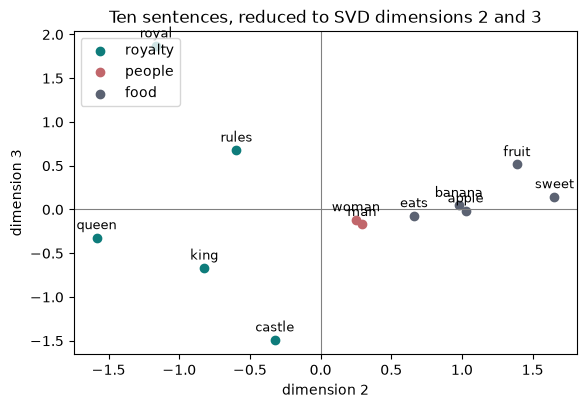

In [8]:
emb2 = U[:, :2] * S[:2]
print("### compression")
print("  one-hot / count row :", V, "numbers per word")
print("  svd embedding       :", d, "numbers per word")
vs_book("king vs queen (2-D)", cosine(emb2, "king", "queen"), 0.996, "{:.3f}")
vs_book("king vs banana (2-D)", cosine(emb2, "king", "banana"), 0.141, "{:.3f}")
first = (U[:, 0] * S[0])
print(f"\nwords with a negative first coordinate: {int((first < 0).sum())} of {V}"
      "   (the book: every single word)")
vs_book("first coordinate, closest to zero", first.max(), -0.70, "{:.2f}")
vs_book("first coordinate, most negative", first.min(), -2.14, "{:.2f}")

BOOK_TOY_COORDS = {
    "king": (-0.824, -0.667),
    "queen": (-1.585, -0.321),
    "royal": (-1.163, 1.871),
    "castle": (-0.324, -1.489),
    "rules": (-0.595, 0.68),
    "man": (0.292, -0.17),
    "woman": (0.249, -0.115),
    "apple": (1.026, -0.015),
    "banana": (0.978, 0.048),
    "fruit": (1.388, 0.514),
    "sweet": (1.655, 0.147),
    "eats": (0.661, -0.07),
}

emb3 = U[:, :3] * S[:3]
diffs = [max(abs(emb3[idx[w], 1] - x), abs(emb3[idx[w], 2] - y)) for w, (x, y) in BOOK_TOY_COORDS.items()]
print(f"figure coordinates: largest difference from the book's widget {max(diffs):.4f} "
      f"over {len(diffs)} words")

groups = {"royalty": ["king", "queen", "royal", "castle", "rules"], "people": ["man", "woman"],
          "food": ["apple", "banana", "fruit", "sweet", "eats"]}
fig, ax = plt.subplots(figsize=(6.5, 4.2))
for (label, words), colour in zip(groups.items(), ["#0E7C7B", "#C1666B", "#5B6272"]):
    xs, ys = emb3[[idx[w] for w in words], 1], emb3[[idx[w] for w in words], 2]
    ax.scatter(xs, ys, color=colour, label=label)
    for w, x, y in zip(words, xs, ys):
        ax.annotate(w, (x, y), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=9)
ax.axhline(0, color="grey", lw=0.8)
ax.axvline(0, color="grey", lw=0.8)
ax.set_xlabel("dimension 2")
ax.set_ylabel("dimension 3")
ax.set_title("Ten sentences, reduced to SVD dimensions 2 and 3")
ax.legend(loc="upper left")
plt.show()

## 3. Saymaktan tahmin etmeye: word2vec

[Bölümdeki kısım](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/03-gommeler.html#saymaktan-tahmin-etmeye-word2vec). Skip-gram merkez kelimeyi alıyor
ve çevresindeki her kelimeyi tahmin ediyor. Bölümdeki etkileşimli araç bir cümleyi eğitim çiftlerine
bölüyor; burada aynısı var: aracın varsayılan cümlesi, penceresi ve merkez konumu için.

In [9]:
sentence = "the pump failed during the night shift".split()
WINDOW_DEMO = 2
pairs = [(sentence[i], sentence[j], i)
         for i in range(len(sentence))
         for j in range(max(0, i - WINDOW_DEMO), min(len(sentence), i + WINDOW_DEMO + 1)) if i != j]
centre = 1
print(f"centre '{sentence[centre]}' produces {sum(p[2] == centre for p in pairs)} pairs:",
      [(a, b) for a, b, i in pairs if i == centre])
print(f"the whole sentence produces {len(pairs)} pairs")
print(f"\na 6-billion-token corpus with window 5 gives up to 2 x 5 = 10 pairs per token: "
      f"about {6e9 * 10 / 1e9:.0f} billion (the book: about 60 billion)")

centre 'pump' produces 3 pairs: [('pump', 'the'), ('pump', 'failed'), ('pump', 'during')]
the whole sentence produces 22 pairs

a 6-billion-token corpus with window 5 gives up to 2 x 5 = 10 pairs per token: about 60 billion (the book: about 60 billion)


### Negatif örnekleme, elle tek bir güncelleme

[Bölümdeki kısım](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/03-gommeler.html#negatif-örnekleme-bir-lojistik-regresyondur). Bölüm dört boyutta
tek bir güncellemeyi elle yapıyor: merkez kelime `failed`, gerçek eşi `pump`, örneklenen
sahte kelime `opera`. Hücre o paragraftaki her sayıyı yeniden hesaplıyor. Sonra vektörleri
0,05 öğrenme oranıyla hareket ettiriyor: önce yalnızca merkez vektörünü, sonra gerçek bir
uygulamada olduğu gibi üçünü birden güncelleyerek.

In [10]:
def sig(z):
    return 1.0 / (1.0 + np.exp(-z))


v_failed = np.array([0.4, -0.2, 0.7, 0.1])
u_pump = np.array([0.5, 0.1, 0.6, -0.3])
u_opera = np.array([-0.3, 0.6, -0.2, 0.4])

z_real, z_fake = v_failed @ u_pump, v_failed @ u_opera
vs_book("failed . pump", z_real, 0.57, "{:.2f}")
vs_book("sigma(0.57)", sig(z_real), 0.639, "{:.3f}")
vs_book("loss, real pair", -np.log(sig(z_real)), 0.448, "{:.3f}")
vs_book("failed . opera", z_fake, -0.34, "{:.2f}")
vs_book("sigma(0.34)", sig(-z_fake), 0.584, "{:.3f}")
vs_book("loss, fake pair", -np.log(sig(-z_fake)), 0.538, "{:.3f}")

r_real, r_fake = sig(z_real) - 1, sig(z_fake) - 0          # tahmin eksi hedef
vs_book("residual, pump", r_real, -0.361, "{:.3f}")
vs_book("residual, opera", r_fake, 0.416, "{:.3f}")
g_v = r_real * u_pump + r_fake * u_opera
vs_book_line("g_v", "(" + ", ".join(f"{x:.3f}" for x in g_v) + ")", "(-0.305, 0.213, -0.300, 0.275)")

lr = 0.05
v_new = v_failed - lr * g_v                                 # yalnızca merkez vektörü
vs_book("failed . pump, centre updated", v_new @ u_pump, 0.590, "{:.3f}")
vs_book("failed . opera, centre updated", v_new @ u_opera, -0.359, "{:.3f}")
u_pump_new = u_pump - lr * r_real * v_failed                # bağlam vektörleri de
u_opera_new = u_opera - lr * r_fake * v_failed
vs_book("failed . pump, all updated", v_new @ u_pump_new, 0.603, "{:.3f}")
vs_book("failed . opera, all updated", v_new @ u_opera_new, -0.374, "{:.3f}")
print(f"\nhow much further the full update moved each dot product: "
      f"pump {(v_new @ u_pump_new - z_real) / (v_new @ u_pump - z_real):.2f}x, "
      f"opera {(v_new @ u_opera_new - z_fake) / (v_new @ u_opera - z_fake):.2f}x   "
      "(the book: roughly 1.7 times)")

failed . pump                        this run       0.57   book       0.57   same as the book
sigma(0.57)                          this run      0.639   book      0.639   same as the book
loss, real pair                      this run      0.448   book      0.448   same as the book
failed . opera                       this run      -0.34   book      -0.34   same as the book
sigma(0.34)                          this run      0.584   book      0.584   same as the book
loss, fake pair                      this run      0.538   book      0.538   same as the book
residual, pump                       this run     -0.361   book     -0.361   same as the book
residual, opera                      this run      0.416   book      0.416   same as the book
  g_v          (-0.305, 0.213, -0.300, 0.275)   [same as the book]
failed . pump, centre updated        this run      0.590   book      0.590   same as the book
failed . opera, centre updated       this run     -0.359   book     -0.359   same as th

**Nasıl okunur.** Bölümün elle yaptığı güncellemedeki her sayı yeniden üretiliyor.
Kapanıştaki oran bir yuvarlama: bölüm, tam güncellemenin iki iç çarpımı "kabaca 1,7 katı
mesafe" taşıdığını söylüyor; tam oranlar 1,66 ve 1,77.

Bölümdeki etkileşimli araç iç çarpımı sürükleyip iki kayıp terimini izlemenize izin veriyor. Durağan
bir sürümü aynı noktayı gösteriyor: her terim modelin zaten haklı olduğu yerde yumuşak, fena
hâlde yanıldığı yerde dik. Güncellemelerin kendi kendini sınırlamasını sağlayan da bu.

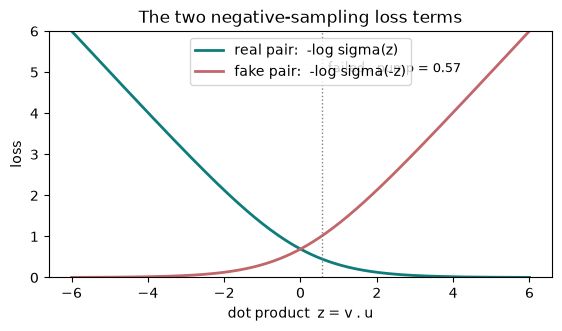

In [11]:
z = np.linspace(-6, 6, 241)
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(z, -np.log(sig(z)), color="#0E7C7B", lw=2, label="real pair:  -log sigma(z)")
ax.plot(z, -np.log(sig(-z)), color="#C1666B", lw=2, label="fake pair:  -log sigma(-z)")
ax.axvline(z_real, color="grey", ls=":", lw=1)
ax.annotate("failed . pump = 0.57", (z_real, 5), xytext=(4, 0), textcoords="offset points", fontsize=9)
ax.set_xlabel("dot product  z = v . u")
ax.set_ylabel("loss")
ax.set_ylim(0, 6)
ax.legend()
ax.set_title("The two negative-sampling loss terms")
plt.show()

### word2vec'in başarısını belirleyen dört eğitim tercihi

[Bölümdeki kısım](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/03-gommeler.html#word2vecin-başarısını-belirleyen-dört-eğitim-tercihi). Bölüm dört
tercih sayıyor: negatif sayısı $K$, bağlam penceresi, sık kelimelerin altörneklenmesi ve
0,75 üssüyle gürültü dağılımı. İlk ikisi bu notebook'ta değiştirebileceğiniz ayarlar:
aşağıdaki sıfırdan modelde `K` ve `WINDOW`, 2. kısmın sayma kodunda `W` (1. alıştırma).
Bu hücre öbür ikisine sayı koyuyor. Önce bölümün, altörneklemenin neyi attığını gösteren
tablosu: word2vec'in C kaynağındaki formülle (aşağıdaki eğitim kodunun kullandığı formül),
yanında makaledeki farklı formülle. Sonra 0,75 üssünün aritmetiği ve negatif örnekleme
şeklindeki maliyet oranı.

In [12]:
t = 1e-3
print(f"{'share of corpus':<17}{'p_keep (C source)':>19}{'discarded':>11}{'book':>14}{'paper: discard':>17}")
for f, book_keep, book_discard in [(0.05, "0.16", "84%"), (0.01, "0.42", "58%"),
                                   (0.001, "1.00", "0%"), (0.0001, "1.00", "0%")]:
    keep_f = min(1.0, (math.sqrt(f / t) + 1) * t / f)
    ours = f"{keep_f:.2f}  {100 * (1 - keep_f):>5.0f}%"
    paper = max(0.0, 1 - math.sqrt(t / f))
    verdict = "same" if (f"{keep_f:.2f}", f"{100 * (1 - keep_f):.0f}%") == (book_keep, book_discard) else "DIFFERS"
    print(f"{100 * f:>14.2g}%  {keep_f:>18.2f}{100 * (1 - keep_f):>10.0f}%{book_keep + ' / ' + book_discard:>14}"
          f"{100 * paper:>16.0f}%   [{verdict}]")

print()
vs_book("0.5^0.75 is larger than 0.5 by, %", 100 * (0.5**0.75 / 0.5 - 1), 19, "{:.0f}")
vs_book("0.001^0.75 / 0.001", 0.001**0.75 / 0.001, 5.6, "{:.1f}")
vs_book("5000^0.75", 5000**0.75, 595, "{:.0f}")
vs_book("gap narrows by a factor of about", 5000 / 5000**0.75, 8, "{:.0f}")
vs_book("softmax / negative sampling, nearest 1,000", round(400_000 / 6, -3), 67_000, "{:,.0f}")

share of corpus    p_keep (C source)  discarded          book   paper: discard
             5%                0.16        84%    0.16 / 84%              86%   [same]
             1%                0.42        58%    0.42 / 58%              68%   [same]
           0.1%                1.00         0%     1.00 / 0%               0%   [same]
          0.01%                1.00         0%     1.00 / 0%               0%   [same]

0.5^0.75 is larger than 0.5 by, %    this run         19   book         19   same as the book
0.001^0.75 / 0.001                   this run        5.6   book        5.6   same as the book
5000^0.75                            this run        595   book        595   same as the book
gap narrows by a factor of about     this run          8   book          8   same as the book
softmax / negative sampling, nearest 1,000 this run     67,000   book     67,000   same as the book


**Nasıl okunur.** Derlemin %5'ini oluşturan bir kelimede C kaynağındaki formül geçişlerin
%16'sını tutuyor; makaledeki formül %84 yerine %86'sını atardı. İkisi kuyrukta anlaşıyor:
eşiğin altındaki hiçbir şeye dokunulmuyor. Son satır, bölümün şeklindeki "kabaca 67.000
kat daha ucuz": 400.000 iç çarpıma karşı 1 + 5; tam oran 66.667.

### Sıfırdan yazmak: veri

[Bölümdeki kısım](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/03-gommeler.html#uygulama-word2veci-sıfırdan-yazmak). Bölüm negatif örneklemeli
skip-gram'i altmış satır kadar NumPy ile, `text8`'in ilk 40 milyon karakteri üzerinde
eğitiyor. `text8`, İngilizce Wikipedia'nın temizlenmiş bir dökümü (Matt Mahoney'nin
benchmark dosyası; gensim-data onun için bir lisans belirtmiyor, Wikipedia metni ise
CC BY-SA).

Kod burada üç hücreye bölündü; böylece eğitim atlansa bile ucuz kısım çalışıyor. Bu ilk
hücre bölümün koduyla, eğitim döngüsüne kadar, satır satır aynı. Ardından gelen yazdırma
satırları bizim: bölüm bu sayımları basıyor ama listesinde onları basan satırlar yok.

**Neye bakacaksınız:** her sayım tam tutmalı. Altörnekleme çekimi `default_rng(0)`
kullanıyor, dolayısıyla tuttuğu token sayısı bile sabit.

In [13]:
import gzip, time
from collections import Counter
import numpy as np
import gensim.downloader as api

rng = np.random.default_rng(0)

with gzip.open(api.load("text8", return_path=True), "rt") as f:
    raw = f.read(40_000_000).split()

MIN_COUNT = 20
counts = Counter(raw)
vocab = [w for w, c in counts.most_common() if c >= MIN_COUNT]
idx = {w: i for i, w in enumerate(vocab)}
V = len(vocab)

total = sum(counts[w] for w in vocab)
freq = np.array([counts[w] / total for w in vocab])
keep = np.minimum(1.0, (np.sqrt(freq / 1e-3) + 1) * (1e-3 / freq))

ids = np.array([idx[w] for w in raw if w in idx], dtype=np.int32)
ids = ids[rng.random(len(ids)) < keep[ids]]          # altörnekleme

noise = freq ** 0.75                                  # 0.75 üssü
noise /= noise.sum()
cum = np.cumsum(noise)

D, K, WINDOW, EPOCHS, LR0 = 100, 5, 5, 3, 0.02
Wc = ((rng.random((V, D)) - 0.5) / D).astype(np.float32)   # merkez vektörleri
Wo = np.zeros((V, D), dtype=np.float32)                    # bağlam vektörleri

# İki basitleştirme: (1) Pencere 5'te sabit; dinamik pencere kullanılmıyor.
# (2) text8 tek bir token akışı olarak işleniyor. Özgün cümle ve belge
# sınırları korunmadığı için sınırlar arasında yapay bağlam çiftleri
# oluşabilir. Ayrı belgelerle çalışırken çiftleri belge içinde kurun.
centres, contexts = [], []
for off in range(1, WINDOW + 1):
    centres.append(ids[:-off]); contexts.append(ids[off:])
    centres.append(ids[off:]); contexts.append(ids[:-off])
centres = np.concatenate(centres)
contexts = np.concatenate(contexts)
N = len(centres)

BATCH = 2048
n_batches = N // BATCH

def sigmoid(x):
    # Taşmaya dayanıklı sigmoid; skoru yapay olarak [-8, 8] ile kısıtlamaz.
    return np.exp(-np.logaddexp(0.0, -x))

# ── kitabın listesinde yok: bastığı sayımlar, bu koşununkilerin yanında ──
vs_book("tokens read", len(raw), 6_794_527, "{:,}")
vs_book("vocabulary (min_count=20)", V, 18_677, "{:,}")
vs_book("in-vocabulary tokens", total, 6_397_826, "{:,}")
vs_book("tokens after subsampling", len(ids), 4_698_743, "{:,}")
vs_book("subsampling discarded, %", 100 * (1 - len(ids) / total), 26.6, "{:.1f}")
vs_book("training pairs", N, 46_987_400, "{:,}")
print(f"batches per epoch: {n_batches:,}")

tokens read                          this run  6,794,527   book  6,794,527   same as the book
vocabulary (min_count=20)            this run     18,677   book     18,677   same as the book
in-vocabulary tokens                 this run  6,397,826   book  6,397,826   same as the book
tokens after subsampling             this run  4,698,743   book  4,698,743   same as the book
subsampling discarded, %             this run       26.6   book       26.6   same as the book
training pairs                       this run 46,987,400   book 46,987,400   same as the book
batches per epoch: 22,943


Bölümün *Bir adımda hangi vektörler güncellenir?* kısmı bu modelin ölçeğini veriyor.
$K = 5$ negatifli tek bir eğitim çifti en fazla yedi farklı satıra dokunuyor: $\mathbf{W}$'den merkez
kelimenin satırı ve $\mathbf{W}'$'den $K + 1$ satır. Tam bir softmax merkez satırına ve
*bütün* çıktı satırlarına dokunurdu.

In [14]:
rows_total = 2 * V
vs_book("rows in the two matrices", rows_total, 37_354, "{:,}")
vs_book("parameters", rows_total * D, 3_735_400, "{:,}")
vs_book("share of rows one pair touches, %", 100 * (1 + (K + 1)) / rows_total, 0.019, "{:.3f}")
vs_book("rows touched by a full softmax", 1 + V, 18_678, "{:,}")
vs_book("softmax / negative sampling", (1 + V) / (1 + K + 1), 2_668, "{:,.0f}")

rows in the two matrices             this run     37,354   book     37,354   same as the book
parameters                           this run  3,735,400   book  3,735,400   same as the book
share of rows one pair touches, %    this run      0.019   book      0.019   same as the book
rows touched by a full softmax       this run     18,678   book     18,678   same as the book
softmax / negative sampling          this run      2,668   book      2,668   same as the book


### Sıfırdan yazmak: eğitim

**Ağır hücre.** Bölüm `trained in 611s` bildiriyor; bu makinede yaklaşık 10 dakika sürdü.
`ANLP_SKIP_HEAVY=1` altında aynı döngü, kodun çalıştığını sınayan kısa bir deneme olarak
epoch başına 50 batch (toplam 150) koşuyor ve eğitilmiş vektörlere ihtiyaç duyan sonraki
her hücre karşılaştırmasını atlıyor.

Döngünün gövdesi bölümün, satır satır. İki şey eklendi, ikisi de işaretli:

- **Kayıp kaydı.** Bölüm kayıpları basıyor ama listesi nasıl bastığını göstermiyor. İlk
  batch'in kaybı tam olarak kontrol edilebilir: bağlam vektörleri sıfırdan başlıyor,
  dolayısıyla her skor $\sigma(0) = 0{,}5$ ve $K + 1 = 6$ sütun üzerinden toplanan kayıp
  $6 \ln 2 = 4{,}159$. Her epoch'un sonu için bu hücre, o epoch'un son 1.000 batch'inin
  ortalama kaybını bildiriyor; bölüm de üç sayısı için aynı pencereyi belirtiyor.
- Kayıt, batch'in iç çarpımlarını yeniden hesaplıyor ve `rng`'den hiçbir şey çekmiyor;
  dolayısıyla vektörler kayıt olsa da olmasa da aynı. `score` yerine iç çarpımlardan
  hesaplıyor, çünkü $z$ büyükken $\log(1 - \sigma(z))$ float32'de hassasiyet kaybediyor.

Bölümün `sigmoid`'i taşmaya dayanıklı $\exp(-\log(1 + e^{-x}))$ biçiminde. Listenin önceki
sürümü skoru önce $[-8, 8]$ aralığına kırpıyordu; aynı seed ile iki sürüm de basılan
hassasiyette aynı kayıpları, komşu listelerini ve benchmark puanlarını veriyor.

**Neye bakacaksınız:** kayıp ilk epoch'ta hızla düşüyor, sonra düzleşiyor.

In [15]:
W2V_FULL = not SKIP_HEAVY
LOG_WINDOW = 1_000                     # kayıt tercihi, kitabın değil
if not W2V_FULL:
    n_batches = 50
    print(f"SKIPPED the full run (ANLP_SKIP_HEAVY=1). SMOKE RUN: {EPOCHS} x {n_batches} batches "
          "of the same loop. These vectors are meaningless; later cells will not compare them.")

print("### training")
start = time.perf_counter()
batch_losses = []
for epoch in range(EPOCHS):
    for b in range(n_batches):
        # YERİNE KOYMALI çekiliyor: "3 epoch", veri üzerinde üç geçiş değil,
        # çift sayısının üç katı kadar çift çekimi demek. Çiftlerin yaklaşık
        # %5'i hiç çekilmiyor, bazıları altı kez çekiliyor; bu yüzden buradaki
        # EPOCHS=3 ile gensim'deki epochs=3'ü karşılaştırmayın.
        sl = rng.integers(0, N, BATCH)
        c, o = centres[sl], contexts[sl]
        negs = np.searchsorted(cum, rng.random((BATCH, K))).astype(np.int32)
        targets = np.concatenate([o[:, None], negs], axis=1)   # (B, K+1)
        labels = np.zeros((BATCH, K + 1), dtype=np.float32)
        labels[:, 0] = 1.0                       # ilk sütun gerçek çift

        v = Wc[c]                                              # (B, D)
        u = Wo[targets]                                        # (B, K+1, D)
        score = sigmoid(np.einsum("bkd,bd->bk", u, v))         # (B, K+1)
        err = (score - labels).astype(np.float32)              # artığın ters işaretlisi (tahmin − gözlem)

        lr = LR0 * max(1e-4, 1 - (epoch * n_batches + b) / (EPOCHS * n_batches))
        gv = np.einsum("bk,bkd->bd", err, u)
        gu = err[:, :, None] * v[:, None, :]
        np.clip(gv, -1.0, 1.0, out=gv)
        np.clip(gu, -1.0, 1.0, out=gu)
        np.add.at(Wc, c, -lr * gv)
        np.add.at(Wo, targets.ravel(), (-lr * gu).reshape(-1, D))

        # ── kayıt, kitabın listesinde yok ──
        z_log = np.einsum("bkd,bd->bk", u, v)
        batch_losses.append(float((np.logaddexp(0.0, -z_log[:, 0]) + np.logaddexp(0.0, z_log[:, 1:]).sum(axis=1)).mean()))
        if epoch == 0 and b == 0:
            print(f"  epoch 1    0.0%  loss {batch_losses[0]:6.3f}")
    print(f"  epoch {epoch + 1}  100.0%  loss {np.mean(batch_losses[-min(LOG_WINDOW, n_batches):]):6.3f}"
          f"   (mean of the last {min(LOG_WINDOW, n_batches)} batches)")

E = Wc / (np.linalg.norm(Wc, axis=1, keepdims=True) + 1e-9)
train_seconds = time.perf_counter() - start
print(f"  trained in {train_seconds:.0f}s   (the book: 611s, on its machine)\n")

vs_book("first-batch loss, 6 ln 2", batch_losses[0], 4.159, "{:.3f}")
BOOK_EPOCH_LOSS = [2.409, 2.368, 2.350]
for e in range(EPOCHS):
    ours = np.mean(batch_losses[(e + 1) * n_batches - min(LOG_WINDOW, n_batches):(e + 1) * n_batches])
    vs_book(f"epoch {e + 1} loss (last 1,000 batches)", ours, BOOK_EPOCH_LOSS[e], "{:.3f}",
            note=None if W2V_FULL else "smoke run")

### training
  epoch 1    0.0%  loss  4.159


  epoch 1  100.0%  loss  2.409   (mean of the last 1000 batches)


  epoch 2  100.0%  loss  2.368   (mean of the last 1000 batches)


  epoch 3  100.0%  loss  2.350   (mean of the last 1000 batches)
  trained in 628s   (the book: 611s, on its machine)

first-batch loss, 6 ln 2             this run      4.159   book      4.159   same as the book
epoch 1 loss (last 1,000 batches)    this run      2.409   book      2.409   same as the book
epoch 2 loss (last 1,000 batches)    this run      2.368   book      2.368   same as the book
epoch 3 loss (last 1,000 batches)    this run      2.350   book      2.350   same as the book


**En yakın komşular.** Bölüm yedi kelimenin en yakın beş komşusunu basıyor. Yazdırma kodu
bizim; vektörler bölümün `E`'si: birim uzunluğa ölçeklenmiş merkez vektörleri.

**Neye bakacaksınız:** ülkeler ülkelerin, haftanın günleri günlerin yanında; hepsi 6,8
milyon token'dan ve altmış satır NumPy'dan. Bir de `pump`: Wikipedia'da nadir bir kelime ve
komşuları çok daha zayıf.

In [16]:
def scratch_neighbours(word, k=5):
    sims = E @ E[idx[word]]
    order = [i for i in np.argsort(-sims, kind="stable") if i != idx[word]][:k]
    return ", ".join(f"{vocab[i]} {sims[i]:.2f}" for i in order)


BOOK_NN_SCRATCH = {
    "king": "consort 0.75, kings 0.75, isabella 0.75, aram 0.74, regent 0.73",
    "france": "spain 0.79, italy 0.75, netherlands 0.74, switzerland 0.73, portugal 0.72",
    "physics": "mechanics 0.82, quantum 0.80, bose 0.80, chemistry 0.78, bohr 0.76",
    "monday": "friday 0.87, thursday 0.85, weekend 0.84, tuesday 0.84, wednesday 0.83",
    "car": "racing 0.74, cars 0.74, driver 0.70, automobile 0.69, motor 0.68",
    "three": "four 0.95, five 0.93, two 0.91, six 0.91, one 0.89",
    "pump": "ignition 0.88, pedals 0.87, injected 0.87, compartment 0.86, oven 0.86",
}
print("### nearest neighbours, from ~60 lines of NumPy")
if W2V_FULL:
    for w, book_line in BOOK_NN_SCRATCH.items():
        vs_book_line(w, scratch_neighbours(w), book_line)
else:
    print("SKIPPED: the vectors come from the smoke run (ANLP_SKIP_HEAVY=1).")

### nearest neighbours, from ~60 lines of NumPy
  king         consort 0.75, kings 0.75, isabella 0.75, aram 0.74, regent 0.73   [same as the book]
  france       spain 0.79, italy 0.75, netherlands 0.74, switzerland 0.73, portugal 0.72   [same as the book]
  physics      mechanics 0.82, quantum 0.80, bose 0.80, chemistry 0.78, bohr 0.76   [same as the book]
  monday       friday 0.87, thursday 0.85, weekend 0.84, tuesday 0.84, wednesday 0.83   [same as the book]
  car          racing 0.74, cars 0.74, driver 0.70, automobile 0.69, motor 0.68   [same as the book]
  three        four 0.95, five 0.93, two 0.91, six 0.91, one 0.89   [same as the book]
  pump         ignition 0.88, pedals 0.87, injected 0.87, compartment 0.86, oven 0.86   [same as the book]


### Sezgi kontrolü: `np.add.at` burada neden gradyan kırpması istiyor?

Bölümün cevabı, batch'lemenin güncellemeleri üst üste yığması: `np.add.at` tekrarlanan bir
indeksin bütün gradyanlarını biriktirip toplamı tek adımda uyguluyor. Böylece 2.048 çiftlik
bir batch'te birçok kez görünen sık bir kelime, hiç hareket etmemiş bir vektörden
hesaplanmış birçok güncelleme alıyor. Bölüm sık bir kelimenin "yüz kez" görünebileceğini
söylüyor.

Hücre, döngünün yaptığı gibi bir batch çekip sayıyor. Kendi rastgele üretecini kullanıyor,
dolayısıyla `rng`'yi bozmuyor.

**Neye bakacaksınız:** hedef satırlar arasındaki en büyük sayı ve hangi kelimeye ait olduğu.
Negatifler, altörneklemeden önceki düzleştirilmiş *ham* frekanslardan çekiliyor. Bu yüzden
en sık kelimeler, altörnekleme merkez olarak geçişlerinin çoğunu atmış olsa da, negatif
olarak geri gelip duruyor.

In [17]:
demo_rng = np.random.default_rng(1)
sl = demo_rng.integers(0, N, BATCH)
c_demo = centres[sl]
negs_demo = np.searchsorted(cum, demo_rng.random((BATCH, K)))
targets_demo = np.concatenate([contexts[sl][:, None], negs_demo], axis=1)

centre_counts = np.bincount(c_demo, minlength=V)
target_counts = np.bincount(targets_demo.ravel(), minlength=V)
print(f"one batch of {BATCH} pairs, {BATCH * (K + 1):,} target rows")
print(f"most repeated centre word : '{vocab[centre_counts.argmax()]}' x {centre_counts.max()}")
print(f"most repeated target row  : '{vocab[target_counts.argmax()]}' x {target_counts.max()}")
print(f"target rows used more than 50 times in this batch: {int((target_counts > 50).sum())}")

# eğitim dizilerini serbest bırak; sonraki kısımlar yalnızca vocab, idx ve E istiyor
n_text8_tokens = len(raw)
del raw, ids, centres, contexts

one batch of 2048 pairs, 12,288 target rows
most repeated centre word : 'the' x 24
most repeated target row  : 'the' x 206
target rows used more than 50 times in this batch: 11


**Nasıl okunur.** Bu batch'te `the` hedef satırı olarak üst üste 206 güncelleme alıyor;
bölümün "yüz kez"inin iki katı. Oysa merkez olarak yalnızca 24 kez görünüyor. Bölümün
anlattığı durum bu. Bölüm kırpmanın neyi *düzeltmediğini* de not ediyor: `np.clip` her
örneğin gradyanını, `np.add.at` tekrarları toplamadan *önce* sınırlıyor; dolayısıyla bir
satır yine de kabaca (sayı × öğrenme oranı) kadar hareket edebiliyor. Bölümün adını verdiği
temiz çözüm, her satırın biriken gradyanını indeksinin `np.bincount(...)` sayısına bölmek.
Yukarıdaki iki `bincount` çağrısı tam bunu hesaplıyor. Sondaki 7. alıştırma bunu
denemenizi istiyor.

## 4. GloVe: sayma, ama kayıp fonksiyonuyla

[Bölümdeki kısım](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/03-gommeler.html#glove-sayma-ama-kayıp-fonksiyonuyla). GloVe
$\mathbf{v}_w \cdot \mathbf{u}_c + b_w + b_c \approx \log X_{wc}$ eşitliğini ağırlıklı en
küçük karelerle kuruyor: her kelime çifti için sol taraf ile sayımın logaritması arasındaki
farkın karesini alıyor ve ağırlıklı toplamı küçülten vektörleri arıyor. $X$ tablosu yeni bir
şey değil. 2. kısımdaki $C$ matrisi gibi eş-oluşum sayımlarını tutuyor; bu sayımlar
bütün derlem boyunca yerel pencerelerden biriktiriliyor. Yani "küresel istatistik" bitmiş
tabloyu anlatıyor, metni okumanın farklı bir yolunu değil. Ağırlık fonksiyonu sık çiftlere
bir tavan koyuyor ve hiç geçmeyen çiftleri dışarıda bırakıyor. Önce bölümün
$x_{\max} = 100$ için $f(x)$ tablosu.

In [18]:
def glove_weight(x, x_max=100, alpha=0.75):
    return min(1.0, (x / x_max) ** alpha)


for x, book in [(0, 0.00), (1, 0.03), (10, 0.18), (100, 1.00), (100_000, 1.00)]:
    vs_book(f"f({x:,})", glove_weight(x), book, "{:.2f}")

f(0)                                 this run       0.00   book       0.00   same as the book
f(1)                                 this run       0.03   book       0.03   same as the book
f(10)                                this run       0.18   book       0.18   same as the book
f(100)                               this run       1.00   book       1.00   same as the book
f(100,000)                           this run       1.00   book       1.00   same as the book


### Ön eğitimli vektörler

**Ağır hücre.** `glove-wiki-gigaword-100` 134,3 MB'lık bir indirme: 400.000 küçük harfli
kelime, Wikipedia 2014 ve Gigaword 5 üzerinde eğitilmiş, Stanford tarafından Open Data
Commons Public Domain Dedication and License (PDDL) ile yayımlanmış. `ANLP_SKIP_HEAVY=1`
altında hücre onun yerine `glove-wiki-gigaword-50`'yi (69,2 MB) yüklüyor ve altındaki her
GloVe karşılaştırması *not comparable* diyor.

Hücre önce indirmeyi gensim-data'nın yayımladığı MD5 sağlama toplamıyla kontrol ediyor,
sonra bölümün kodunu çalıştırıyor. Bölümün çıktısında, kodunun basmadığı ikinci bir satır
var: *trained on Wikipedia 2014 + Gigaword 5, 6 billion tokens*. Ona en yakın şey
gensim-data kataloğundaki `base_dataset` alanı; burada o basılıyor.

In [19]:
GLOVE_FULL = not SKIP_HEAVY
GLOVE_NAME = "glove-wiki-gigaword-100" if GLOVE_FULL else "glove-wiki-gigaword-50"
GLOVE_NOTE = None if GLOVE_FULL else "skip mode uses glove-wiki-gigaword-50"
if not GLOVE_FULL:
    print("SKIPPED glove-wiki-gigaword-100 (ANLP_SKIP_HEAVY=1). SUBSTITUTE: glove-wiki-gigaword-50, "
          "69.2 MB. No GloVe number below is comparable with the book.\n")

meta = api.info(GLOVE_NAME)
gz_path = Path(api.load(GLOVE_NAME, return_path=True))
md5 = hashlib.md5(gz_path.read_bytes()).hexdigest()
print(f"{meta['file_name']}  {gz_path.stat().st_size / 1e6:.1f} MB  md5 {md5[:12]}…  "
      f"{'matches' if md5 == meta['checksum'] else 'DOES NOT MATCH'} gensim-data's checksum")
print(f"gensim-data base_dataset: {meta['base_dataset']}\n")

# bölümün kodu
g = api.load(GLOVE_NAME)
print("vectors:", len(g.index_to_key), " dimensions:", g.vector_size)
v = g["king"]
print("king[:8] =", np.round(v[:8], 3))
print("norm:", round(float(np.linalg.norm(v)), 3))

print()
vs_book("vectors", len(g.index_to_key), 400_000, "{:,}", note=GLOVE_NOTE)
vs_book("dimensions", g.vector_size, 100, note=GLOVE_NOTE)
vs_book_line("king[:8]", str(np.round(v[:8], 3)), "[-0.323 -0.876  0.22   0.253  0.23   0.739 -0.38  -0.353]",
             note=GLOVE_NOTE)
vs_book("norm of king", float(np.linalg.norm(v)), 6.118, "{:.3f}", note=GLOVE_NOTE)

glove-wiki-gigaword-100.gz  134.3 MB  md5 40ec48186600…  matches gensim-data's checksum
gensim-data base_dataset: Wikipedia 2014 + Gigaword 5 (6B tokens, uncased)



vectors: 400000  dimensions: 100
king[:8] = [-0.323 -0.876  0.22   0.253  0.23   0.739 -0.38  -0.353]
norm: 6.118

vectors                              this run    400,000   book    400,000   same as the book
dimensions                           this run        100   book        100   same as the book
  king[:8]     [-0.323 -0.876  0.22   0.253  0.23   0.739 -0.38  -0.353]   [same as the book]
norm of king                         this run      6.118   book      6.118   same as the book


Bölümün komşu listeleri, bölümün koduyla.

**Neye bakacaksınız:** `turkey`de kuştan iz yok, `python` komedi topluluğunu, programlama
dilini ve hayvanı harmanlıyor, `bank`te yalnızca finansal anlam var. Bağlam ne olursa olsun,
kelime biçimi başına tek vektör.

In [20]:
BOOK_NN_GLOVE = {
    "king": "prince 0.77, queen 0.75, son 0.70, brother 0.70, monarch 0.70, throne 0.69",
    "pump": "pumps 0.84, pumping 0.77, pumped 0.71, gasoline 0.64, fuel 0.63, petrol 0.63",
    "turkey": "ankara 0.75, turkish 0.72, greece 0.71, syria 0.70, bulgaria 0.69, russia 0.69",
    "python": "monty 0.69, php 0.59, perl 0.58, cleese 0.54, flipper 0.51, ruby 0.51",
    "bank": "banks 0.81, banking 0.75, credit 0.70, investment 0.69, financial 0.68, securities 0.67",
}
for w in ["king", "pump", "turkey", "python", "bank"]:
    line = ", ".join(f"{a} {b:.2f}" for a, b in g.most_similar(w, topn=6))
    vs_book_line(w, line, BOOK_NN_GLOVE[w], note=GLOVE_NOTE)

  king         prince 0.77, queen 0.75, son 0.70, brother 0.70, monarch 0.70, throne 0.69   [same as the book]
  pump         pumps 0.84, pumping 0.77, pumped 0.71, gasoline 0.64, fuel 0.63, petrol 0.63   [same as the book]
  turkey       ankara 0.75, turkish 0.72, greece 0.71, syria 0.70, bulgaria 0.69, russia 0.69   [same as the book]
  python       monty 0.69, php 0.59, perl 0.58, cleese 0.54, flipper 0.51, ruby 0.51   [same as the book]
  bank         banks 0.81, banking 0.75, credit 0.70, investment 0.69, financial 0.68, securities 0.67   [same as the book]


## 5. Kelime analojileri ve değerlendirme koşulları

[Bölümdeki kısım](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/03-gommeler.html#meşhur-analoji-ve-gizlediği-şey). Önce meşhur sonuç, `gensim`
üzerinden; `gensim` her girdi vektörünü birim uzunluğa ölçekliyor ve üç girdi kelimesini
cevaplarından çıkarıyor. Sonra bölümün karşılaştırması: aynı puanlar, bu filtreyle ve
filtresiz iki kez sıralanıyor. `topn=None`, bütün sözlük için puanları döndürüyor.

In [21]:
res = g.most_similar(positive=["king", "woman"], negative=["man"], topn=5)
print("gensim most_similar, input words excluded")
for w, s in res:
    print(f"  {w:<12} {s:.4f}")
vs_book_line("as a list", ", ".join(f"{w} {s:.4f}" for w, s in res),
             "queen 0.7699, monarch 0.6843, throne 0.6756, daughter 0.6595, princess 0.6521", note=GLOVE_NOTE)

print("\nthe chapter's comparison: the same scores, with and without the input filter")
BOOK_FILTER = {"unfiltered": "king 0.8361, queen 0.7699, monarch 0.6843, throne 0.6756, daughter 0.6595, princess 0.6521",
               "filtered": "queen 0.7699, monarch 0.6843, throne 0.6756, daughter 0.6595, princess 0.6521, prince 0.6517"}
sims = g.most_similar(positive=["king", "woman"], negative=["man"], topn=None)
inputs = {"king", "man", "woman"}
order = np.argsort(-sims)
for label, excluded in [("unfiltered", set()), ("filtered", inputs)]:
    chosen = [i for i in order if g.index_to_key[i] not in excluded][:6]
    print(label)
    for i in chosen:
        print(f"  {g.index_to_key[i]:<12} {sims[i]:.4f}")
    vs_book_line("as a list", ", ".join(f"{g.index_to_key[i]} {sims[i]:.4f}" for i in chosen),
                 BOOK_FILTER[label], note=GLOVE_NOTE)

gensim most_similar, input words excluded
  queen        0.7699
  monarch      0.6843
  throne       0.6756
  daughter     0.6595
  princess     0.6521
  as a list    queen 0.7699, monarch 0.6843, throne 0.6756, daughter 0.6595, princess 0.6521   [same as the book]

the chapter's comparison: the same scores, with and without the input filter
unfiltered
  king         0.8361
  queen        0.7699
  monarch      0.6843
  throne       0.6756
  daughter     0.6595
  princess     0.6521
  as a list    king 0.8361, queen 0.7699, monarch 0.6843, throne 0.6756, daughter 0.6595, princess 0.6521   [same as the book]
filtered
  queen        0.7699
  monarch      0.6843
  throne       0.6756
  daughter     0.6595
  princess     0.6521
  prince       0.6517
  as a list    queen 0.7699, monarch 0.6843, throne 0.6756, daughter 0.6595, princess 0.6521, prince 0.6517   [same as the book]


**Nasıl okunur.** Puanlar sabit tutulduğunda filtresiz en yakın vektör `king`in kendisi,
`queen` ikinci. Girdi kelimelerini çıkarmak farklı bir aday kümesi tanımlıyor ve `queen` o
kümede birinci oluyor. Aday kümesi görevin tanımının parçası.

Bölüm, girdiler birimleştirilmeden toplandığında ne olduğunu da veriyor: puanlar biraz
değişiyor, sıralamanın başı aynı kalıyor. Sıradaki hücre o varyantı hesaplıyor.

In [22]:
Nv = g.get_normed_vectors()
target = g["king"] - g["man"] + g["woman"]
target /= np.linalg.norm(target)
sims_raw = Nv @ target
print("unfiltered, inputs added without normalizing them first:")
for i in np.argsort(-sims_raw)[:6]:
    print(f"  {g.index_to_key[i]:<12} {sims_raw[i]:.4f}")
vs_book("king, raw sum", float(sims_raw[g.key_to_index["king"]]), 0.8552, "{:.4f}", note=GLOVE_NOTE)
vs_book("queen, raw sum", float(sims_raw[g.key_to_index["queen"]]), 0.7834, "{:.4f}", note=GLOVE_NOTE)

unfiltered, inputs added without normalizing them first:


  king         0.8552
  queen        0.7834
  monarch      0.6934
  throne       0.6833
  daughter     0.6809
  prince       0.6713
king, raw sum                        this run     0.8552   book     0.8552   same as the book
queen, raw sum                       this run     0.7834   book     0.7834   same as the book


`king` iki aritmetikte de birinci geliyor; değişen yalnızca puanlar.

### Analoji aracı

Bölümdeki etkileşimli araç sekiz analoji tutuyor; her biri için ilk on iki filtresiz cevap
var ve puanlar `gensim`'in hesapladığı biçimde (yukarıdaki karşılaştırmayla aynı hesap).
Hücre sekizini de yeniden hesaplıyor, kelimeleri ve puanları aracın verisiyle
karşılaştırıyor; bu notebook o veriyi bölümün kaynağından kopyaladı. Sonra aracın altında
yazan iddiaları kontrol ediyor.

In [23]:
BOOK_EXPLORER = {
    ("king", "man", "woman"): "king 0.8361, queen 0.7699, monarch 0.6843, throne 0.6756, daughter 0.6595, princess 0.6521, prince 0.6517, elizabeth 0.6465, mother 0.6312, emperor 0.6106, wife 0.6099, father 0.6053",
    ("paris", "france", "italy"): "rome 0.8190, italy 0.7528, milan 0.7376, paris 0.7216, naples 0.7118, venice 0.7015, turin 0.6995, italian 0.6801, vienna 0.6685, genoa 0.6453, berlin 0.6428, prohertrib 0.6410",
    ("walking", "walk", "swim"): "swim 0.8385, swimming 0.8009, surfing 0.6603, swam 0.6448, rowing 0.6413, jogging 0.6376, biking 0.6344, kayaking 0.6220, canoeing 0.6219, sailing 0.6125, diving 0.6108, jumping 0.6086",
    ("bigger", "big", "small"): "larger 0.8925, smaller 0.8694, small 0.8250, large 0.7933, bigger 0.7481, tiny 0.7139, size 0.6559, relatively 0.6467, significant 0.6340, sized 0.6325, less 0.6315, fewer 0.6195",
    ("madrid", "spain", "germany"): "munich 0.8562, berlin 0.8023, frankfurt 0.7604, dortmund 0.7430, hamburg 0.7416, stuttgart 0.7375, germany 0.7326, bayern 0.7267, cologne 0.7240, leverkusen 0.6984, madrid 0.6821, borussia 0.6711",
    ("windows", "microsoft", "google"): "windows 0.8330, window 0.6895, google 0.6674, web 0.6273, portal 0.6030, walls 0.5955, dashboard 0.5954, portals 0.5929, browser 0.5785, clicking 0.5782, lights 0.5746, screens 0.5690",
    ("mice", "mouse", "goose"): "goose 0.7279, cows 0.5407, geese 0.5354, turkeys 0.5325, elk 0.5168, calves 0.5009, pigs 0.4998, infants 0.4988, rats 0.4984, chickens 0.4949, grouse 0.4937, diets 0.4915",
    ("einstein", "physics", "biology"): "einstein 0.7982, genetics 0.7085, biology 0.6298, evolutionary 0.5772, freud 0.5656, biochemistry 0.5592, neuroscience 0.5459, molecular 0.5410, genetic 0.5350, evolution 0.5183, theory 0.5037, immunology 0.5024",
}


def unfiltered(a, b, c, k=12):
    s = g.most_similar(positive=[a, c], negative=[b], topn=None)
    return [(g.index_to_key[i], float(s[i])) for i in np.argsort(-s)[:k]]


top_is_input = 0
for (a, b, c), book_line in BOOK_EXPLORER.items():
    rows = unfiltered(a, b, c)
    top_is_input += rows[0][0] in (a, b, c)
    line = ", ".join(f"{w} {s:.4f}" for w, s in rows)
    vs_book_line(f"{a} - {b} + {c}", line, book_line, note=GLOVE_NOTE)

print()
vs_book("analogies whose top answer is an input", top_is_input, 5, note=GLOVE_NOTE)
ranked = [w for w, _ in unfiltered("mice", "mouse", "goose", k=1000)]
geese_rank = ranked.index("geese") + 1 if "geese" in ranked else "> 1000"
vs_book("rank of 'geese' (unfiltered)", geese_rank, 3, note=GLOVE_NOTE)
kept = [w for w in ranked if w not in ("mice", "mouse", "goose")]
vs_book("rank of 'geese' (inputs removed)", kept.index("geese") + 1 if "geese" in kept else "> 1000", 2,
        note=GLOVE_NOTE)
first_de = unfiltered("madrid", "spain", "germany")[0][0]
vs_book_line("madrid - spain + germany, top", first_de, "munich", note=GLOVE_NOTE)

  king - man + woman king 0.8361, queen 0.7699, monarch 0.6843, throne 0.6756, daughter 0.6595, princess 0.6521, prince 0.6517, elizabeth 0.6465, mother 0.6312, emperor 0.6106, wife 0.6099, father 0.6053   [same as the book]


  paris - france + italy rome 0.8190, italy 0.7528, milan 0.7376, paris 0.7216, naples 0.7118, venice 0.7015, turin 0.6995, italian 0.6801, vienna 0.6685, genoa 0.6453, berlin 0.6428, prohertrib 0.6410   [same as the book]


  walking - walk + swim swim 0.8385, swimming 0.8009, surfing 0.6603, swam 0.6448, rowing 0.6413, jogging 0.6376, biking 0.6344, kayaking 0.6220, canoeing 0.6219, sailing 0.6125, diving 0.6108, jumping 0.6086   [same as the book]
  bigger - big + small larger 0.8925, smaller 0.8694, small 0.8250, large 0.7933, bigger 0.7481, tiny 0.7139, size 0.6559, relatively 0.6467, significant 0.6340, sized 0.6325, less 0.6315, fewer 0.6195   [same as the book]
  madrid - spain + germany munich 0.8562, berlin 0.8023, frankfurt 0.7604, dortmund 0.7430, hamburg 0.7416, stuttgart 0.7375, germany 0.7326, bayern 0.7267, cologne 0.7240, leverkusen 0.6984, madrid 0.6821, borussia 0.6711   [same as the book]
  windows - microsoft + google windows 0.8330, window 0.6895, google 0.6674, web 0.6273, portal 0.6030, walls 0.5955, dashboard 0.5954, portals 0.5929, browser 0.5785, clicking 0.5782, lights 0.5746, screens 0.5690   [same as the book]
  mice - mouse + goose goose 0.7279, cows 0.5407, geese 0.5354, tur

  einstein - physics + biology einstein 0.7982, genetics 0.7085, biology 0.6298, evolutionary 0.5772, freud 0.5656, biochemistry 0.5592, neuroscience 0.5459, molecular 0.5410, genetic 0.5350, evolution 0.5183, theory 0.5037, immunology 0.5024   [same as the book]

analogies whose top answer is an input this run          5   book          5   same as the book
rank of 'geese' (unfiltered)         this run          3   book          3   same as the book
rank of 'geese' (inputs removed)     this run          2   book          2   same as the book


  madrid - spain + germany, top munich   [same as the book]


**Nasıl okunur.** Araçtaki 96 kelime ve puanın hepsi yeniden üretiliyor. `geese`
*filtresiz* listede üçüncü; önünde `goose` ve `cows` var. Girdi kelimeleri çıkarılınca
ikinci; filtreyi açtığınızda araç böyle ayarlanıyor. Sekiz örneğin beşinde filtresiz ilk
cevap girdilerden biri; bu oran genel analoji başarısı hakkında bir şey söylemiyor.

### Otuz kelime, iki boyuta izdüşürülmüş

Bölümün şekli otuz kelimeyi *o otuz vektörün* ilk iki temel bileşenine göre yerleştiriyor
ve bunların varyansın %37,5'ini koruduğunu söylüyor. Aracın koordinatları, en büyük mutlak
koordinat 1 olacak biçimde ölçeklenmiş. Hücre izdüşümü yeniden hesaplayıp aracın
koordinatlarıyla karşılaştırıyor. Bir temel bileşenin işareti keyfîdir; karşılaştırma bu
yüzden her eksenin ters dönmesine izin veriyor.

variance kept by 2 components, %     this run       37.5   book       37.5   same as the book
largest coordinate difference from the widget: 0.0005


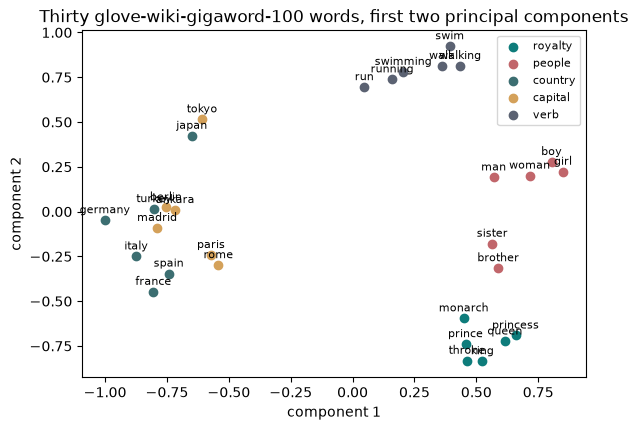

In [24]:
from sklearn.decomposition import PCA

BOOK_PROJECTION = {
    "king": (0.524, -0.835, "royalty"),
    "queen": (0.615, -0.725, "royalty"),
    "prince": (0.456, -0.74, "royalty"),
    "princess": (0.658, -0.692, "royalty"),
    "monarch": (0.449, -0.596, "royalty"),
    "throne": (0.462, -0.832, "royalty"),
    "man": (0.57, 0.191, "people"),
    "woman": (0.715, 0.201, "people"),
    "boy": (0.804, 0.277, "people"),
    "girl": (0.85, 0.223, "people"),
    "brother": (0.588, -0.316, "people"),
    "sister": (0.564, -0.179, "people"),
    "france": (-0.805, -0.448, "country"),
    "italy": (-0.874, -0.25, "country"),
    "spain": (-0.743, -0.346, "country"),
    "germany": (-1.0, -0.048, "country"),
    "japan": (-0.65, 0.423, "country"),
    "turkey": (-0.802, 0.014, "country"),
    "paris": (-0.572, -0.242, "capital"),
    "rome": (-0.542, -0.299, "capital"),
    "madrid": (-0.79, -0.091, "capital"),
    "berlin": (-0.754, 0.024, "capital"),
    "tokyo": (-0.608, 0.515, "capital"),
    "ankara": (-0.717, 0.009, "capital"),
    "walk": (0.359, 0.813, "verb"),
    "walking": (0.434, 0.813, "verb"),
    "swim": (0.393, 0.923, "verb"),
    "swimming": (0.205, 0.78, "verb"),
    "run": (0.047, 0.695, "verb"),
    "running": (0.16, 0.738, "verb"),
}

words30 = list(BOOK_PROJECTION)
X30 = np.array([g[w] for w in words30])
pca = PCA(n_components=2).fit(X30)
Z = pca.transform(X30)
Z = Z / np.abs(Z).max()
book_xy = np.array([BOOK_PROJECTION[w][:2] for w in words30])
for axis in range(2):                                  # bir bileşenin işareti keyfîdir
    if np.corrcoef(Z[:, axis], book_xy[:, axis])[0, 1] < 0:
        Z[:, axis] *= -1
vs_book("variance kept by 2 components, %", 100 * pca.explained_variance_ratio_.sum(), 37.5, "{:.1f}",
        note=GLOVE_NOTE)
print(f"largest coordinate difference from the widget: {np.abs(Z - book_xy).max():.4f}")

colours = {"royalty": "#0E7C7B", "people": "#C1666B", "country": "#3C6E71", "capital": "#D4A15A", "verb": "#5B6272"}
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for group, colour in colours.items():
    members = [i for i, w in enumerate(words30) if BOOK_PROJECTION[w][2] == group]
    ax.scatter(Z[members, 0], Z[members, 1], color=colour, label=group)
    for i in members:
        ax.annotate(words30[i], Z[i], textcoords="offset points", xytext=(0, 5), ha="center", fontsize=8)
ax.set_xlabel("component 1")
ax.set_ylabel("component 2")
ax.set_title(f"Thirty {GLOVE_NAME} words, first two principal components")
ax.legend(fontsize=8)
plt.show()

Resmi bölümün uyarısıyla okuyun: bileşenler tam da bu otuz noktayı ayırmak için seçiliyor
ve varyansın yalnızca üçte biri kadarını koruyor. Bu kısımdaki GloVe benzerlikleri özgün
100 boyutlu vektörlerle hesaplanıyor; izdüşüm yalnızca görselleştirme için kullanılıyor.

## 6. fastText: parçalardan yapılmış kelimeler

[Bölümdeki kısım](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/03-gommeler.html#fasttext-parçalardan-yapılmış-kelimeler). fastText bir kelimeyi
karakter n-gram'larının toplamı olarak temsil ediyor; model kelimeyi gördüyse buna kelimenin
bütünü için bir vektör de ekleniyor. Önce bölümün şeklindeki aritmetik: 3-gram'larla `pumps`
ve fastText'in varsayılan 3–6 boylarıyla `pumpage` gibi görülmemiş bir kelimenin 22 parçaya
ayrıştığı iddiası. Sonra etkileşimli aracın varsayılan Türkçe kelime çifti.

In [25]:
def char_ngrams(word, n):
    w = f"<{word}>"
    return [w[i:i + n] for i in range(len(w) - n + 1)]


print("pumps, 3-grams:  ", char_ngrams("pumps", 3), "+ the word <pumps>")
print("pumpage, 3-grams:", char_ngrams("pumpage", 3))
shared = set(char_ngrams("pumps", 3)) & set(char_ngrams("pumpage", 3))
print("shared 3-grams:  ", sorted(shared))
vs_book("pumpage, n-grams of size 3 to 6", sum(len(char_ngrams("pumpage", n)) for n in range(3, 7)), 22)

grams = char_ngrams("kitaplarımızdaki", 4)
also = set(char_ngrams("kitaplar", 4))
print(f"\nkitaplarımızdaki: {len(grams)} n-grams of size 4, "
      f"{sum(gm in also for gm in grams)} of them also in 'kitaplar':")
print(grams)

pumps, 3-grams:   ['<pu', 'pum', 'ump', 'mps', 'ps>'] + the word <pumps>
pumpage, 3-grams: ['<pu', 'pum', 'ump', 'mpa', 'pag', 'age', 'ge>']
shared 3-grams:   ['<pu', 'pum', 'ump']
pumpage, n-grams of size 3 to 6      this run         22   book         22   same as the book

kitaplarımızdaki: 15 n-grams of size 4, 6 of them also in 'kitaplar':
['<kit', 'kita', 'itap', 'tapl', 'apla', 'plar', 'ları', 'arım', 'rımı', 'ımız', 'mızd', 'ızda', 'zdak', 'daki', 'aki>']


### Derlemler: kitabınkiler değil, onların yerine konmuş bir yedek

Bölüm "karşılaştırılabilir büyüklükte iki Wikipedia örneklemi; biri Türkçe, biri İngilizce"
karşılaştırıyor. Hangi örneklemler olduğunu, nasıl çekildiklerini ya da nasıl token'lara
ayrıldıklarını söylemiyor; dolayısıyla derlem sayıları burada yeniden üretilemiyor. Bu
notebook yapabildiği en yakın okuyuşu kuruyor:

- **Örneklemler.** Hugging Face'teki `wikimedia/wikipedia` dökümlerinin (`20231101.tr` ve
  `20231101.en`) veri kümesi sırasıyla ilk maddeleri, *tam olarak* bölümün token
  sayılarında kesilmiş: 1.458.213 Türkçe ve 1.828.840 İngilizce token. Hugging Face veri
  kümesi görüntüleyici API'si üzerinden, istek başına 100 madde olarak çekiliyor ve JSON
  olarak önbelleğe alınıyor. Wikipedia metni CC BY-SA lisanslı; veri kümesi kartı
  CC BY-SA 3.0 ve GFDL diyor.
- **Satırlar**, madde metninin boş olmayan satırları.
- **Token'lar**, küçük harfe çevirdikten sonraki `\w+` dizileri. Türkçe için küçük harfe
  çevirme Türkçe kurallarıyla yapılıyor (`I`→`ı`, `İ`→`i`), 4. bölümdeki gibi.

İki örneklem de bölümün token sayılarıyla eşleştiği için tip sayıları büyüklükçe
karşılaştırılabilir. Yine de farklı metin bunlar; dolayısıyla aşağıdaki her kitap değeri
bağlam için gösteriliyor ve *not comparable* diye işaretleniyor.

**Neye bakacaksınız:** Türkçe, *daha az* token'dan çok daha fazla farklı kelime biçimi
üretiyor.

In [26]:
ROWS_API = "https://datasets-server.huggingface.co/rows"
TR_LOWER = str.maketrans({"I": "ı", "İ": "i"})


def tr_tokenize(text):
    return re.findall(r"\w+", text.translate(TR_LOWER).lower())


def en_tokenize(text):
    return re.findall(r"\w+", text.lower())


def wikipedia_sample(config, n_tokens, tokenize):
    """Bir wikimedia/wikipedia dökümünün ilk maddeleri, n_tokens'a ulaşacak kadar. Önbelleğe alınır."""
    path = CACHE / f"wikipedia-{config}-first-{n_tokens}-tokens.json"
    if not path.exists():
        texts, seen, offset = [], 0, 0
        while seen < n_tokens:
            params = {"dataset": "wikimedia/wikipedia", "config": config, "split": "train",
                      "offset": offset, "length": 100}
            for attempt in range(6):                        # görüntüleyici API'si geçici 429 ve 502 hataları veriyor
                r = requests.get(ROWS_API, params=params, timeout=120)
                if r.status_code != 429 and r.status_code < 500:
                    break
                time.sleep(5 * 2**attempt)
            r.raise_for_status()
            for item in r.json()["rows"]:
                texts.append(item["row"]["text"])
                seen += len(tokenize(item["row"]["text"]))
                if seen >= n_tokens:
                    break
            offset += 100
        path.write_text(json.dumps(texts, ensure_ascii=False), encoding="utf-8")
    raw_json = path.read_bytes()
    print(f"{config}: {len(json.loads(raw_json)):,} articles cached, {len(raw_json) / 1e6:.1f} MB, "
          f"sha256 {hashlib.sha256(raw_json).hexdigest()[:12]}")
    return json.loads(raw_json)


def to_lines(texts, tokenize, n_tokens):
    """Token'lara ayrılmış boş olmayan satırlar, tam n_tokens'ta kesilmiş."""
    out, used = [], 0
    for text in texts:
        for line in text.split("\n"):
            toks = tokenize(line)[: n_tokens - used]
            if toks:
                out.append(toks)
                used += len(toks)
            if used >= n_tokens:
                return out
    return out


tr_lines = to_lines(wikipedia_sample("20231101.tr", 1_458_213, tr_tokenize), tr_tokenize, 1_458_213)
en_lines = to_lines(wikipedia_sample("20231101.en", 1_828_840, en_tokenize), en_tokenize, 1_828_840)

NOTE_CORPUS = "different corpus"
BOOK_CORPORA = {"turkish": (103_040, 1_458_213, 138_578), "english": (44_079, 1_828_840, 78_140)}
print("\n### corpora")
for name, lines in [("turkish", tr_lines), ("english", en_lines)]:
    n_tok = sum(map(len, lines))
    n_types = len({w for line in lines for w in line})
    b_lines, b_tok, b_types = BOOK_CORPORA[name]
    print(f"  {name:<8} {len(lines):>7} lines {n_tok:>10} tokens {n_types:>9} types")
    vs_book(f"    {name} tokens", n_tok, b_tok, "{:,}")
    vs_book(f"    {name} types", n_types, b_types, "{:,}", note=NOTE_CORPUS)
    vs_book(f"    {name} lines", len(lines), b_lines, "{:,}", note=NOTE_CORPUS)

20231101.tr: 1,486 articles cached, 11.5 MB, sha256 ed6a2c5e19dd


20231101.en: 434 articles cached, 11.6 MB, sha256 2b19e767f302

### corpora


  turkish   116120 lines    1458213 tokens    134380 types
    turkish tokens                   this run  1,458,213   book  1,458,213   same as the book
    turkish types                    this run    134,380   book    138,578   not comparable: different corpus
    turkish lines                    this run    116,120   book    103,040   not comparable: different corpus
  english    56235 lines    1828840 tokens     81619 types
    english tokens                   this run  1,828,840   book  1,828,840   same as the book
    english types                    this run     81,619   book     78,140   not comparable: different corpus
    english lines                    this run     56,235   book     44,079   not comparable: different corpus


Bölümün sözlük faturasına dair üç ölçümü: yeni kelime biçimlerinin ne hızla gelmeye devam
ettiği, sözlüğün ne kadarının tam bir kez görüldüğü ve token'ların ilk %90'ında eğitip son
%10'unda test ettiğinizde sözlük dışı oranı.

Son ölçüm o %10'un *nasıl* seçildiğine duyarlı. Hücre bu yüzden bizim diye etiketlenmiş
ikinci bir sürüm ekliyor: *satırların* %10'u, sabit bir tohumla rastgele çekilmiş.

In [27]:
BOOK_GROWTH = {"turkish": "250k:45688  500k:73435  750k:97412  1000k:112644  1250k:126389",
               "english": "250k:22869  500k:34016  750k:42854  1000k:52347  1250k:60178"}
BOOK_HAPAX = {"turkish": "50.0% of types are hapax (69296 of 138578)",
              "english": "46.7% of types are hapax (36503 of 78140)"}
BOOK_OOV = {"turkish": "7.33% of tokens unseen, 28.99% of types unseen",
            "english": "4.72% of tokens unseen, 23.29% of types unseen"}


def oov_rates(train_tokens, test_tokens):
    seen = set(train_tokens)
    test_types = set(test_tokens)
    return (100 * sum(w not in seen for w in test_tokens) / len(test_tokens),
            100 * sum(w not in seen for w in test_types) / len(test_types))


results = {}
for name, lines in [("turkish", tr_lines), ("english", en_lines)]:
    stream = [w for line in lines for w in line]
    seen, growth = set(), []
    for i, w in enumerate(stream, start=1):
        seen.add(w)
        if i % 250_000 == 0 and len(growth) < 5:
            growth.append(f"{i // 1000}k:{len(seen)}")
    type_counts = Counter(stream)
    hapax = sum(1 for n in type_counts.values() if n == 1)
    cut = int(0.9 * len(stream))
    last_tok, last_typ = oov_rates(stream[:cut], stream[cut:])
    line_rng = np.random.default_rng(0)
    held_out = line_rng.random(len(lines)) < 0.1
    rand_tok, rand_typ = oov_rates([w for l, h in zip(lines, held_out) if not h for w in l],
                                   [w for l, h in zip(lines, held_out) if h for w in l])
    results[name] = (growth, hapax, len(type_counts), last_tok, last_typ, rand_tok, rand_typ)

print("### vocabulary growth: new word forms per million tokens")
for name, r in results.items():
    vs_book_line(name, "  ".join(r[0]), BOOK_GROWTH[name], note=NOTE_CORPUS)
print("\n### the tail: how much of the vocabulary is seen exactly once")
for name, r in results.items():
    vs_book_line(name, f"{100 * r[1] / r[2]:.1f}% of types are hapax ({r[1]} of {r[2]})", BOOK_HAPAX[name],
                 note=NOTE_CORPUS)
print("\n### out-of-vocabulary rate: train on 90%, test on the last 10%")
for name, r in results.items():
    vs_book_line(name, f"{r[3]:.2f}% of tokens unseen, {r[4]:.2f}% of types unseen", BOOK_OOV[name],
                 note=NOTE_CORPUS)
print("\n### ours, not the book's: hold out a random 10% of lines instead")
for name, r in results.items():
    print(f"  {name:<12} {r[5]:.2f}% of tokens unseen, {r[6]:.2f}% of types unseen")

### vocabulary growth: new word forms per million tokens
  turkish      250k:45801  500k:73651  750k:96914  1000k:111998  1250k:125686
    book       250k:45688  500k:73435  750k:97412  1000k:112644  1250k:126389   [not comparable: different corpus]
  english      250k:23856  500k:36038  750k:45401  1000k:53461  1250k:63178
    book       250k:22869  500k:34016  750k:42854  1000k:52347  1250k:60178   [not comparable: different corpus]

### the tail: how much of the vocabulary is seen exactly once
  turkish      50.5% of types are hapax (67796 of 134380)
    book       50.0% of types are hapax (69296 of 138578)   [not comparable: different corpus]
  english      47.0% of types are hapax (38399 of 81619)
    book       46.7% of types are hapax (36503 of 78140)   [not comparable: different corpus]

### out-of-vocabulary rate: train on 90%, test on the last 10%
  turkish      4.21% of tokens unseen, 21.87% of types unseen
    book       7.33% of tokens unseen, 28.99% of types unseen   [not

**Nasıl okunur.** Büyüme ve hapax payı, aynı ansiklopedinin farklı bir örnekleminde
bölümünkilere yakın çıkıyor: bir milyon token'da Türkçe, İngilizcenin iki katından fazla
biçim görmüş ve eğri düzleşmiyor.

Kırılgan olan sözlük dışı oranı. Bu örneklemin *son* %10'u ayrılınca İngilizce Türkçenin
*üstünde* çıkıyor; bölümün tersi. İngilizce örneklem 434 uzun madde. Son onda biri, ilk
%90'ın hiç anmadığı adlarla dolu, yeni konularda birkaç düzine madde. Rastgele satırları
ayırmak bu konu kaymasını kaldırıyor ve bölümün sıralaması geri geliyor: Türkçe,
İngilizcenin epey üstünde. Bölümün örneklemleri muhtemelen konuları daha dengeli
karıştırıyordu. Her durumda, ayrılmış bir parçadaki sözlük dışı oranı dili ölçtüğü kadar
bölmeyi de ölçüyor. Böyle bir oran bildirirken ayrılan metnin nasıl seçildiğini de söyleyin.

### Aynı Türkçe örneklem üzerinde word2vec ve fastText

Bölüm iki modeli de Türkçe örneklemi üzerinde eğitiyor ama ayarları basmıyor. Sıradaki
hücre 4. bölümün `gensim` ayarlarını kullanıyor (skip-gram, pencere 5, beş negatif,
3–6 boyunda n-gram'lar, 500.000 kova, tek işçi, tohum 42); `min_count` ve `epochs`
gensim'in varsayılanlarında, 5 ve 5'te bırakıldı. İki ayar denedik. 4. bölümün kendi
`min_count=2, epochs=10` ayarı bu bölümünkilerden daha uzak komşu listeleri verdi; bu yüzden
bu ikili tutuldu. İngilizce örneklem üzerindeki ikinci bir fastText modeli yazım hatası
örnekleri için. Eğitim toplamda bir dakika kadar sürüyor.

In [28]:
from gensim.models import FastText, Word2Vec

SETTINGS = dict(vector_size=100, window=5, min_count=5, sg=1, negative=5, epochs=5, workers=1, seed=42)
start = time.perf_counter()
with quiet_gensim("three models"):
    w2v_tr = Word2Vec(tr_lines, **SETTINGS)
    ft_tr = FastText(tr_lines, **SETTINGS, min_n=3, max_n=6, bucket=500_000)
    ft_en = FastText(en_lines, **SETTINGS, min_n=3, max_n=6, bucket=500_000)
print(f"trained in {time.perf_counter() - start:.0f}s; vocabularies: Turkish {len(w2v_tr.wv):,}, "
      f"English {len(ft_en.wv):,}")


def top(model, word, k):
    return ", ".join(f"{w} {s:.2f}" for w, s in model.wv.most_similar(word, topn=k))


print("\n### a word the corpus never saw")
BOOK_UNSEEN = {"kitaplarımızdaki": "kitapları 0.91, kitapların 0.91, kitaplıkları 0.90, kitaplarda 0.90",
               "bilgisayarcılık": "bilgisayara 0.96, bilgisayarlı 0.96, bilgisayar 0.96, bilgisayarı 0.96"}
for word, book_line in BOOK_UNSEEN.items():
    print(f"  {word:<18} in word2vec vocab: {word in w2v_tr.wv.key_to_index}   "
          f"in fastText vocab: {word in ft_tr.wv.key_to_index}")
    vs_book_line("  fastText", top(ft_tr, word, 4), book_line, note=NOTE_CORPUS)
    try:
        w2v_tr.wv[word]
        print("    word2vec answers (the word is in this sample's vocabulary)")
    except KeyError:
        print("    word2vec raises: KeyError")

print("\n### typos, fastText on the English sample")
BOOK_TYPOS = {"philosphy": "philosophy 0.96, philosophie 0.95, philosophies 0.94, philology 0.94, philo 0.93",
              "governmentt": "government 0.98, governments 0.94, governmental 0.93, governs 0.91, govern 0.91"}
for word, book_line in BOOK_TYPOS.items():
    print(f"  {word:<15} in vocab: {word in ft_en.wv.key_to_index}")
    vs_book_line("  fastText", top(ft_en, word, 5), book_line, note=NOTE_CORPUS)

(three models: gensim printed its 'Exception ignored in our_dot_float' note 16 times)
trained in 65s; vocabularies: Turkish 26,941, English 22,179

### a word the corpus never saw
  kitaplarımızdaki   in word2vec vocab: False   in fastText vocab: False
    fastText   kitapları 0.92, kitapların 0.90, kitaplar 0.90, kitaplara 0.89
    book       kitapları 0.91, kitapların 0.91, kitaplıkları 0.90, kitaplarda 0.90   [not comparable: different corpus]
    word2vec raises: KeyError
  bilgisayarcılık    in word2vec vocab: False   in fastText vocab: False
    fastText   bilgisayara 0.97, bilgisayarlı 0.97, bilgisayar 0.97, bilgisayarı 0.96
    book       bilgisayara 0.96, bilgisayarlı 0.96, bilgisayar 0.96, bilgisayarı 0.96   [not comparable: different corpus]
    word2vec raises: KeyError

### typos, fastText on the English sample
  philosphy       in vocab: False
    fastText   philosophie 0.96, philosophy 0.96, philology 0.94, philosophies 0.94, philostratus 0.93
    book       philosophy 0

### Alt kelimelerin bedeli

Bölümün iki biçimbilim örneği: fastText'in çekimli biçimleri, word2vec'in anlamsal
komşuları döndürdüğü `kitap`; ve fastText'in yazıma boğulduğu `yaz` (mevsim, ama "yazmak"
da). Sonra ölçtüğü tek bedel: `kitap` ile ilgisiz `kitle` arasındaki benzerlik.

In [29]:
print("### morphology: does fastText put inflected forms together?")
BOOK_MORPH = {("ft", "kitap"): "kitapta 0.96, kitaba 0.95, kitab 0.94, kitabın 0.94, kitabı 0.93",
              ("w2v", "kitap"): "eseri 0.81, makale 0.80, eseriyle 0.80, kitabın 0.80, kitaplar 0.79",
              ("ft", "yaz"): "yao 0.78, yağ 0.77, yağdı 0.77, yayoi 0.76, yay 0.75",
              ("w2v", "yaz"): "kış 0.86, olimpiyatları 0.84, aylarında 0.83, gündönümü 0.80"}
for (kind, word), book_line in BOOK_MORPH.items():
    model = ft_tr if kind == "ft" else w2v_tr
    k = len(book_line.split(", "))
    vs_book_line(f"{kind:<3} {word}", top(model, word, k), book_line, note=NOTE_CORPUS)

print("\n### the price, measured")
vs_book("kitap / kitle, fastText", float(ft_tr.wv.similarity("kitap", "kitle")), 0.667, "{:+.3f}", note=NOTE_CORPUS)
vs_book("kitap / kitle, word2vec", float(w2v_tr.wv.similarity("kitap", "kitle")), 0.446, "{:+.3f}", note=NOTE_CORPUS)

### morphology: does fastText put inflected forms together?
  ft  kitap    kitapta 0.96, kitab 0.95, kitabın 0.95, kitabı 0.94, kitaplık 0.93
    book       kitapta 0.96, kitaba 0.95, kitab 0.94, kitabın 0.94, kitabı 0.93   [not comparable: different corpus]
  w2v kitap    makale 0.82, eseriyle 0.80, kitabın 0.78, yazılan 0.78, eseri 0.77
    book       eseri 0.81, makale 0.80, eseriyle 0.80, kitabın 0.80, kitaplar 0.79   [not comparable: different corpus]
  ft  yaz      yarık 0.76, yağ 0.75, yayoi 0.75, yay 0.75, yağdı 0.74
    book       yao 0.78, yağ 0.77, yağdı 0.77, yayoi 0.76, yay 0.75   [not comparable: different corpus]
  w2v yaz      kış 0.90, olimpiyatları 0.87, aylarında 0.77, atlanta 0.77
    book       kış 0.86, olimpiyatları 0.84, aylarında 0.83, gündönümü 0.80   [not comparable: different corpus]

### the price, measured
kitap / kitle, fastText              this run     +0.714   book     +0.667   not comparable: different corpus
kitap / kitle, word2vec              this 

**Nasıl okunur.** Farklı bir Wikipedia örnekleminde ve tahmin etmek zorunda kaldığımız
ayarlarla, bölümün nitel bulgularının hepsi yeniden ortaya çıkıyor. fastText hiç görmediği
Türkçe kelimeler ve İngilizce yazım hataları için cevap veriyor. word2vec'in `makale` ve
`eser` bulduğu yerde `kitap`ın çekimli biçimlerini bir araya getiriyor. `yaz` için `yağ` ve
`yay` gibi yazım komşuları döndürüyor; word2vec orada `kış` buluyor. Ve `kitap`/`kitle`
çiftine word2vec'ten epey yüksek puan veriyor. Listelerin kendisi farklı; farklı metinde
öyle olmak zorunda.

Bölümün kuralı: **fastText'i kapsama ve görev başarısıyla değerlendirin.** Karakter
parçalarını paylaşmak sözlük dışı ve çekimli biçimlerde işe yarıyor; yalnızca yazılışı
benzeyen kelimeler arasında istenmeyen yakınlık da yaratabiliyor.

## 7. Belgeler vektör olarak

[Bölümdeki kısım](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/03-gommeler.html#belgeler-vektör-olarak). [2. bölümdeki](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/02-metin-veri.html)
aynı dört haber grubu, aynı eğitim/test bölünmesi ve aynı lojistik regresyon. 20 Newsgroups
gönderilerini Ken Lang derledi; scikit-learn onları özgün sunucusundan indiriyor ve onlar
için bir lisans belirtilmiyor.

Bölüm yalnızca `average` fonksiyonunu gösteriyor. Gerisi bölümün anlatımını bizim
okuyuşumuz ve her parça bölümün bastığı bir sayıyla kontrol ediliyor:

- **TF-IDF baseline'ı**, 2. bölümün `TfidfVectorizer(stop_words="english")` satırı.
  Öznitelik sayısı, 32.014, parmak izi.
- **Yoğun yöntemlerin tokenizer'ı** belirtilmemiş. Bölümün kapsama sayıları bir tanesini
  ele veriyor: eğitim gönderilerinde `re.findall(r"[a-z]+", text.lower())` tam olarak
  bölümün 27.681 tipini ve kapsanan 23.395'ini veriyor. Hücre önce bunu kontrol ediyor.

In [30]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline

cats = ["sci.med", "sci.space", "rec.autos", "talk.politics.guns"]
drop = ("headers", "footers", "quotes")
NG_HOME = str(CACHE / "scikit_learn_data")
train = fetch_20newsgroups(subset="train", categories=cats, remove=drop, data_home=NG_HOME)
test = fetch_20newsgroups(subset="test", categories=cats, remove=drop, data_home=NG_HOME)
vs_book("training documents", len(train.data), 2_327, "{:,}")
vs_book("test documents", len(test.data), 1_550, "{:,}")


def tokenize_news(text):
    return re.findall(r"[a-z]+", text.lower())


train_tok = [tokenize_news(t) for t in train.data]
test_tok = [tokenize_news(t) for t in test.data]

print("\n### coverage: how much of the corpus does glove actually know?")
type_counts = Counter(w for doc in train_tok for w in doc)
covered_types = sum(1 for w in type_counts if w in g.key_to_index)
covered_tokens = sum(n for w, n in type_counts.items() if w in g.key_to_index)
vs_book("types in the training posts", len(type_counts), 27_681, "{:,}")
vs_book("types covered", covered_types, 23_395, "{:,}", note=GLOVE_NOTE)
vs_book("types covered, %", 100 * covered_types / len(type_counts), 84.5, "{:.1f}", note=GLOVE_NOTE)
vs_book("tokens covered, %", 100 * covered_tokens / sum(type_counts.values()), 98.6, "{:.1f}", note=GLOVE_NOTE)

training documents                   this run      2,327   book      2,327   same as the book
test documents                       this run      1,550   book      1,550   same as the book

### coverage: how much of the corpus does glove actually know?
types in the training posts          this run     27,681   book     27,681   same as the book
types covered                        this run     23,395   book     23,395   same as the book
types covered, %                     this run       84.5   book       84.5   same as the book
tokens covered, %                    this run       98.6   book       98.6   same as the book


Şimdi tablo. Kalan okuyuşlar:

- **Ortalaması alınmış GloVe**, bölümün `average` fonksiyonu, değiştirilmeden.
- **IDF ağırlıklı ortalaması alınmış GloVe**, her token'ın vektörünü TF-IDF baseline'ının
  vektörleştiricisindeki IDF'iyle ağırlıklandırıyor. O vektörleştiricinin tanımadığı
  kelimeler (stop word'ler, tek harfli token'lar) 0 ağırlık alıyor. Bu, bölümün 0,822'sini
  yeniden üretiyor; aynı şeyin stop word'süz hâli de üretiyor. Yani bu, uyan bir okuyuş;
  geri kazanılmış bir liste değil. Üçüncü ondalıkta da kırılgan: `np.average` float64'te
  çalışıyor, aynı ağırlıklı ortalama float32'de hesaplanınca 0,823 alıyor; bir test belgesi
  fark.
- **doc2vec**, `Doc2Vec(dm=0, vector_size=100, epochs=40)`; gensim'in öbür varsayılanları,
  tek işçi ve tohum 0 ile. Test belgelerinin satırı yok, dolayısıyla vektörleri
  `infer_vector`'dan geliyor. Bir tekrarlanabilirlik tuzağı: `infer_vector` her yeni
  vektörün tohumunu belge metninin Python'daki yerleşik `hash()` değerinden alıyor ve
  `PYTHONHASHSEED` ayarlanmadıkça o hash Python her başladığında değişiyor. Dolayısıyla
  bölümün kendi doc2vec sayısını kimse tam olarak yeniden koşturamaz. Hücre onun yerine
  kararlı bir hash (CRC-32) koyuyor; böylece bu notebook'un sayısı tekrarlanabiliyor.
- **Ortalaması alınmış GloVe + doc2vec**, 100 boyutlu iki vektörü uç uca ekliyor.

Her sınıflandırıcı, 2. bölümdeki gibi
`LogisticRegression(max_iter=2000, random_state=0)`.

In [31]:
import gensim.models.doc2vec as doc2vec_module
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from gensim.models.keyedvectors import pseudorandom_weak_vector


def stable_weak_vector(size, seed_string=None, hashfxn=None):
    """gensim'in çıkarılan vektörler için kendi başlatıcısı; her süreçte aynı kalan bir hash ile."""
    return pseudorandom_weak_vector(size, seed_string=seed_string,
                                    hashfxn=lambda s: zlib.crc32(s.encode("utf-8")))


doc2vec_module.pseudorandom_weak_vector = stable_weak_vector


def average(docs):
    # docs: her elemanı token listesi olan belge listesi (ham metin değil).
    # Sözlük dışı token'lar atlanır; hiç vektörü olmayan belge sıfır satırı kalır.
    out = np.zeros((len(docs), g.vector_size), dtype=np.float32)
    for i, tokens in enumerate(docs):
        if isinstance(tokens, str):
            raise TypeError("each document must be a list of tokens, not a raw string")
        vs = [g[w] for w in tokens if w in g.key_to_index]
        if vs:
            out[i] = np.mean(vs, axis=0)
    return out


def idf_average(docs, idf):
    out = np.zeros((len(docs), g.vector_size), dtype=np.float32)
    for i, d in enumerate(docs):
        words = [w for w in d if w in g.key_to_index and idf.get(w, 0.0) > 0]
        if words:
            out[i] = np.average([g[w] for w in words], axis=0, weights=[idf[w] for w in words])
    return out


def fit_score(X_train, X_test):
    clf = LogisticRegression(max_iter=2000, random_state=0).fit(X_train, train.target)
    return accuracy_score(test.target, clf.predict(X_test))


def doc2vec_vectors(seed):
    model = Doc2Vec([TaggedDocument(d, [i]) for i, d in enumerate(train_tok)],
                    dm=0, vector_size=100, epochs=40, workers=1, seed=seed)
    return (np.array([model.dv[i] for i in range(len(train_tok))]),
            np.array([model.infer_vector(d) for d in test_tok]))


start = time.perf_counter()
baseline = make_pipeline(TfidfVectorizer(stop_words="english"), LogisticRegression(max_iter=2000, random_state=0))
baseline.fit(train.data, train.target)
acc_tfidf = accuracy_score(test.target, baseline.predict(test.data))
n_features = len(baseline[0].get_feature_names_out())

avg_train, avg_test = average(train_tok), average(test_tok)
acc_avg = fit_score(avg_train, avg_test)
idf = dict(zip(baseline[0].get_feature_names_out(), baseline[0].idf_))
acc_idf = fit_score(idf_average(train_tok, idf), idf_average(test_tok, idf))
with quiet_gensim("doc2vec, seed 0"):
    d2v_train, d2v_test = doc2vec_vectors(seed=0)
acc_d2v = fit_score(d2v_train, d2v_test)
acc_both = fit_score(np.hstack([avg_train, d2v_train]), np.hstack([avg_test, d2v_test]))

print("\n### documents as vectors: five representations")
rows = [("tf-idf (chapter 2 baseline)", acc_tfidf, n_features, 0.853, 32_014, None),
        ("averaged glove", acc_avg, g.vector_size, 0.820, 100, GLOVE_NOTE),
        ("idf-weighted averaged glove", acc_idf, g.vector_size, 0.822, 100, GLOVE_NOTE),
        ("doc2vec (PV-DBOW, 40 epochs)", acc_d2v, 100, 0.839, 100, None),
        ("averaged glove + doc2vec", acc_both, g.vector_size + 100, 0.845, 200, GLOVE_NOTE)]
for name, acc, dims, book_acc, book_dims, note in rows:
    print(f"{name:<34} accuracy {acc:.3f}   dimensions {dims:>7}")
print()
for name, acc, dims, book_acc, book_dims, note in rows:
    vs_book(f"{name}", acc, book_acc, "{:.3f}", note=note)
vs_book("tf-idf features", n_features, 32_014, "{:,}")
vs_book("training documents left as zero rows", int((np.abs(avg_train).sum(axis=1) == 0).sum()), 79, note=GLOVE_NOTE)
vs_book("test documents left as zero rows", int((np.abs(avg_test).sum(axis=1) == 0).sum()), 65, note=GLOVE_NOTE)
print(f"\n({time.perf_counter() - start:.0f}s)")

(doc2vec, seed 0: gensim printed its 'Exception ignored in our_dot_float' note 4 times)

### documents as vectors: five representations
tf-idf (chapter 2 baseline)        accuracy 0.853   dimensions   32014
averaged glove                     accuracy 0.820   dimensions     100
idf-weighted averaged glove        accuracy 0.822   dimensions     100
doc2vec (PV-DBOW, 40 epochs)       accuracy 0.830   dimensions     100
averaged glove + doc2vec           accuracy 0.839   dimensions     200

tf-idf (chapter 2 baseline)          this run      0.853   book      0.853   same as the book
averaged glove                       this run      0.820   book      0.820   same as the book
idf-weighted averaged glove          this run      0.822   book      0.822   same as the book
doc2vec (PV-DBOW, 40 epochs)         this run      0.830   book      0.839   DIFFERS from the book
averaged glove + doc2vec             this run      0.839   book      0.845   DIFFERS from the book
tf-idf features             

**doc2vec kendi başına ne kadar oynuyor?** Bölüm doc2vec satırları için eşleştirilmiş test
veremiyor, çünkü kendi doc2vec tahminleri birebir yeniden koşturulamıyor. Bu satırın ne
kadar oynayabildiğini görmenin ucuz yolu seed. Hücre doc2vec'i aynı bölünmede iki seed ile
daha yeniden eğitiyor, sonra bölümün tek bir doğruluk için standart hata aritmetiğini ve
koordinat sayılarının oranını (32.014'e 100) kontrol ediyor.

In [32]:
seed_scores = {0: acc_d2v}
with quiet_gensim("doc2vec, seeds 1 and 2"):
    for seed in [1, 2]:
        seed_scores[seed] = fit_score(*doc2vec_vectors(seed))
print("doc2vec accuracy by seed:", {s: round(a, 3) for s, a in seed_scores.items()},
      f"  range {100 * (max(seed_scores.values()) - min(seed_scores.values())):.1f} points")

n_test = len(test.data)
vs_book("standard error of an accuracy near 0.83", math.sqrt(0.83 * 0.17 / n_test), 0.010, "{:.3f}")
vs_book("tf-idf features / 100 dimensions", 32_014 / 100, 320, "{:.0f}")

(doc2vec, seeds 1 and 2: gensim printed its 'Exception ignored in our_dot_float' note 5 times)
doc2vec accuracy by seed: {0: 0.83, 1: 0.836, 2: 0.834}   range 0.6 points
standard error of an accuracy near 0.83 this run      0.010   book      0.010   same as the book
tf-idf features / 100 dimensions     this run        320   book        320   same as the book


**Eşleştirilmiş karşılaştırma.** Bölümün değerlendirme notu, temsilleri aynı 1.550 test
belgesinde McNemar testiyle karşılaştırıyor: bir modelin doğru, diğerinin yanlış bildiği
belgeleri iki yönde sayın ve iki sayımın rastlantıdan fazla ayrışıp ayrışmadığını sınayın
(ayrışan belgeler üzerinde kesin binom testi). Hücre bunu bölümün bildirdiği üç çift için
yapıyor. Üç karşılaştırma için Bonferroni eşiği 0,05 / 3 ≈ 0,017.

**Neye bakacaksınız:** her satırdaki iki sayım ve hangi farkların eşiğin altında kaldığı.

In [33]:
from scipy.stats import binomtest


def predictions(X_train, X_test):
    return LogisticRegression(max_iter=2000, random_state=0).fit(X_train, train.target).predict(X_test)


pred = {"tf-idf": baseline.predict(test.data),
        "averaged glove": predictions(avg_train, avg_test),
        "idf-weighted glove": predictions(idf_average(train_tok, idf), idf_average(test_tok, idf))}
BOOK_MCNEMAR = {("tf-idf", "averaged glove"): (135, 84, 0.0007, "{:.4f}"),
                ("tf-idf", "idf-weighted glove"): (129, 81, 0.0011, "{:.4f}"),
                ("idf-weighted glove", "averaged glove"): (66, 63, 0.86, "{:.2f}")}
y_test = test.target
for (first, second), (book_first, book_second, book_p, fmt) in BOOK_MCNEMAR.items():
    only_first = int(((pred[first] == y_test) & (pred[second] != y_test)).sum())
    only_second = int(((pred[first] != y_test) & (pred[second] == y_test)).sum())
    p_value = binomtest(only_first, only_first + only_second, 0.5).pvalue
    print(f"{first} vs {second}")
    vs_book(f"  only {first} right", only_first, book_first, note=GLOVE_NOTE)
    vs_book(f"  only {second} right", only_second, book_second, note=GLOVE_NOTE)
    vs_book("  exact McNemar p", p_value, book_p, fmt, note=GLOVE_NOTE)

tf-idf vs averaged glove
  only tf-idf right                  this run        135   book        135   same as the book
  only averaged glove right          this run         84   book         84   same as the book
  exact McNemar p                    this run     0.0007   book     0.0007   same as the book
tf-idf vs idf-weighted glove
  only tf-idf right                  this run        129   book        129   same as the book
  only idf-weighted glove right      this run         81   book         81   same as the book
  exact McNemar p                    this run     0.0011   book     0.0011   same as the book
idf-weighted glove vs averaged glove
  only idf-weighted glove right      this run         66   book         66   same as the book
  only averaged glove right          this run         63   book         63   same as the book
  exact McNemar p                    this run       0.86   book       0.86   same as the book


**Nasıl okunur.** TF-IDF ile iki GloVe ortalamasının her biri arasındaki fark eşiğin
altında; iki ortalama arasındaki 0,2 puanlık fark değil. Tek bir doğruluğun standart hatası
(burada 0,010), aynı belgelerde puanlanan iki modelin farkının standart hatası değildir;
bölümün eşleştirilmiş sayımları kullanmasının nedeni bu.

**Nasıl okunur.** TF-IDF baseline'ı, iki GloVe ortalaması ve kapsama sayıları yeniden
üretiliyor; öznitelik sayısı dâhil. doc2vec satırları tutmuyor. Bu notebook'un okuyuşu,
bölümün 0,839 ve 0,845 bastığı yerde 0,830 ve 0,839 veriyor; iki seed daha, doc2vec'i tek
başına 0,830 ile 0,836 arasında oynatıyor. Ayarlar bölümde yok ve hash yüzünden bölümün
kendi sayısı zaten tam olarak yeniden koşturulamıyor. Bu bölünmede en yüksek doğruluk
TF-IDF satırında; bölüm bunu bütün sınıflandırma ya da erişim görevlerine genellemiyor.

### Ortalama almanın yok ettiği şey

Bölümün dört satırı, sonra bastığı iki sonuç. "Özdeş" burada `np.allclose`. Bölüm bit bit
kontrolü de bildiriyor ve o farklı çıkıyor: aynı float32 sayıları farklı bir sırayla
toplamak, toplamın son bitini değiştirebilir.

In [34]:
a = "the pump failed and the valve is fine".split()
b = "the valve failed and the pump is fine".split()
va = np.mean([g[w] for w in a], axis=0)
vb = np.mean([g[w] for w in b], axis=0)

print("### what averaging destroys")
cos_ab = float(va @ vb / (np.linalg.norm(va) * np.linalg.norm(vb)))
print(f"  cosine of the two averaged vectors: {cos_ab:.4f}")
print(f"  identical: {np.allclose(va, vb)}")
vs_book("cosine", cos_ab, 1.0, "{:.4f}")
vs_book("identical (np.allclose)", np.allclose(va, vb), True)
print()
vs_book("bit for bit (np.array_equal)", np.array_equal(va, vb), False, note=GLOVE_NOTE)
vs_book("largest difference", float(np.abs(va - vb).max()), 1.2e-07, "{:.1e}", note=GLOVE_NOTE)

### what averaging destroys
  cosine of the two averaged vectors: 1.0000
  identical: True
cosine                               this run     1.0000   book     1.0000   same as the book
identical (np.allclose)              this run       True   book       True   same as the book

bit for bit (np.array_equal)         this run      False   book      False   same as the book
largest difference                   this run    1.2e-07   book    1.2e-07   same as the book


### Sezgi kontrolü 4: ortalaması alınmış iki belge arasında 0,95 kosinüs yüksek mi?

Bölümün cevabı bunu aynı belgelerde ölçüyor: ortalama GloVe vektörü olan bütün eğitim
belgesi çiftlerini alın ve kosinüslerinin dağılımına bakın.

**Neye bakacaksınız:** 0,95'in bu dağılımda nereye düştüğü ve iki belge farklı haber
gruplarından geldiğinde payın ne kadar az değiştiği.

In [35]:
has_vector = np.linalg.norm(avg_train, axis=1) > 0
unit_docs = avg_train[has_vector] / np.linalg.norm(avg_train[has_vector], axis=1, keepdims=True)
labels_docs = train.target[has_vector]
upper = np.triu_indices(len(unit_docs), k=1)
pair_cos = (unit_docs @ unit_docs.T)[upper]
same_group = (labels_docs[:, None] == labels_docs[None, :])[upper]

vs_book("documents with a vector", len(unit_docs), 2_248, "{:,}", note=GLOVE_NOTE)
vs_book("mean cosine, all pairs", float(pair_cos.mean()), 0.944, "{:.3f}", note=GLOVE_NOTE)
vs_book("median cosine, all pairs", float(np.median(pair_cos)), 0.961, "{:.3f}", note=GLOVE_NOTE)
vs_book("pairs above 0.95, %", 100 * float((pair_cos > 0.95).mean()), 65.6, "{:.1f}", note=GLOVE_NOTE)
vs_book("different-newsgroup pairs above 0.95, %", 100 * float((pair_cos[~same_group] > 0.95).mean()), 63.8,
        "{:.1f}", note=GLOVE_NOTE)
del pair_cos, same_group

documents with a vector              this run      2,248   book      2,248   same as the book
mean cosine, all pairs               this run      0.944   book      0.944   same as the book
median cosine, all pairs             this run      0.961   book      0.961   same as the book
pairs above 0.95, %                  this run       65.6   book       65.6   same as the book
different-newsgroup pairs above 0.95, % this run       63.8   book       63.8   same as the book


**Nasıl okunur.** Bu derlemde 0,95, rastgele bir belge çiftinin aldığı tipik değerin
*altında* kalıyor. Ortalama alma bütün belgelerin paylaştığını koruyor, onları ayıranı
küçültüyor; dolayısıyla ham sayı çok az şey söylüyor. Karar eşiğini benzer, ilgisiz ve zor
negatif olarak etiketlenmiş çiftlerle değerlendirmek gerekiyor.

## 8. Geometrinin sorunları var

[Bölümdeki kısım](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/03-gommeler.html#geometrinin-sorunları-var). Adını koyabilmeniz gereken üç kusur,
ardından kusur olmayan ama bilmeniz gereken iki özellik.

### Bu uzayda kosinüs, benzerlikten çok ilişkililiği yansıtır

Bölüm altı kosinüsü kodsuz basıyor; `g.similarity` tek satırlık okuyuşu.
**Neye bakacaksınız:** `cat`/`dog` karşısında `increase`/`decrease`. Bölüm buna **zıt
anlamlı (antonym) problemi** diyor: zıt anlamlı kelimeler aynı bağlamlarda geçer, bu yüzden
uzayda birbirinden uzakta değil, yakında durur.

In [36]:
for a_w, b_w, book in [("good", "bad", 0.770), ("hot", "cold", 0.725), ("increase", "decrease", 0.881),
                       ("cat", "dog", 0.880), ("cat", "car", 0.311), ("teacher", "student", 0.808)]:
    vs_book(f"  {a_w:<10} {b_w:<10}", float(g.similarity(a_w, b_w)), book, "{:.3f}", note=GLOVE_NOTE)

  good       bad                     this run      0.770   book      0.770   same as the book
  hot        cold                    this run      0.725   book      0.725   same as the book
  increase   decrease                this run      0.881   book      0.881   same as the book
  cat        dog                     this run      0.880   book      0.880   same as the book
  cat        car                     this run      0.311   book      0.311   same as the book
  teacher    student                 this run      0.808   book      0.808   same as the book


### Uzay izotropik değil

[Bölümdeki kısım](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/03-gommeler.html#uzay-izotropik-değil). *İzotropik*, "her yönde aynı" demek. Kelime
vektörleri bütün yönlere eşit dağılsaydı rastgele iki kelime ortalamada dik açı yapar,
ortalama kosinüsleri sıfır olurdu. *Anizotropik* bir uzayda vektörlerin çoğu aynı yana
yatar. Bu yüzden ilgisiz çiftler bile sıfırın üstünde puan alır ve bir kosinüsü neye göre
okuduğunuzun sıfır noktası kayar. Hücre GloVe için o sıfır noktasının nerede olduğunu
ölçüyor.

Bölümün kodu en sık 50.000 kelimeden 4.000'ini örnekliyor ve her çiftin kosinüsünü alıyor;
yaklaşık 8 milyon çift. Kodunun ardındaki beş istatistik, nasıl hesaplandıklarına dair
bizim okuyuşumuz. "Ortalamayı çıkardıktan sonra", örneklemin ortalama vektörünü çıkarıyor
ve kosinüsleri yeniden almadan önce her vektörü birim uzunluğa ölçekliyor. Bölümün
özdeşliği de kontrol ediliyor: ortalama kosinüs ile ortalama vektörün normu aynı sayıyı
iki kez söylüyor.

Etkileşimli aracın histogramı (0,05 genişliğinde kutular) yeniden hesaplanıp kutu kutu
karşılaştırılıyor ve durağan bir şekil olarak çiziliyor.

pairs: 7,998,000
mean cosine between random word pairs this run      0.029   book      0.029   same as the book
std                                  this run      0.119   book      0.119   same as the book
share of pairs with cosine > 0, %    this run       56.9   book       56.9   same as the book
norm of the mean vector              this run      0.171   book      0.171   same as the book
after subtracting the mean, mean cosine this run     -0.000   book     -0.000   same as the book
identity (n |mean|^2 - 1) / (n - 1)  this run      0.029   book      0.029   same as the book



histogram: 60 of 60 bin counts identical to the book's widget


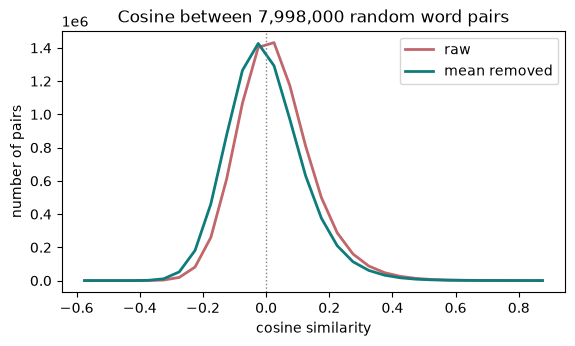

In [37]:
rng = np.random.default_rng(0)
M = g.get_normed_vectors()                       # (400000, 100), birim satırlar
sample = rng.choice(50_000, size=4000, replace=False)   # yalnızca ilk 50 bin
S = M[sample]
vals = (S @ S.T)[np.triu_indices(4000, k=1)]

S_centred = S - S.mean(axis=0)
S_centred /= np.linalg.norm(S_centred, axis=1, keepdims=True)
vals_centred = (S_centred @ S_centred.T)[np.triu_indices(4000, k=1)]
mean_norm = float(np.linalg.norm(S.mean(axis=0)))

print(f"pairs: {len(vals):,}")
vs_book("mean cosine between random word pairs", float(vals.mean()), 0.029, "{:.3f}", note=GLOVE_NOTE)
vs_book("std", float(vals.std()), 0.119, "{:.3f}", note=GLOVE_NOTE)
vs_book("share of pairs with cosine > 0, %", 100 * float((vals > 0).mean()), 56.9, "{:.1f}", note=GLOVE_NOTE)
vs_book("norm of the mean vector", mean_norm, 0.171, "{:.3f}", note=GLOVE_NOTE)
vs_book("after subtracting the mean, mean cosine", float(vals_centred.mean()) + 0.0, -0.000, "{:.3f}",
        note=GLOVE_NOTE)
vs_book("identity (n |mean|^2 - 1) / (n - 1)", (4000 * mean_norm**2 - 1) / 3999, 0.029, "{:.3f}", note=GLOVE_NOTE)

BOOK_HIST_CENTRES = [-0.575, -0.525, -0.475, -0.425, -0.375, -0.325, -0.275, -0.225, -0.175, -0.125, -0.075, -0.025, 0.025, 0.075, 0.125, 0.175, 0.225, 0.275, 0.325, 0.375, 0.425, 0.475, 0.525, 0.575, 0.625, 0.675, 0.725, 0.775, 0.825, 0.875]
BOOK_HIST_RAW = [5, 13, 30, 91, 466, 3292, 19099, 81573, 259774, 611031, 1067028, 1403084, 1431741, 1173616, 810182, 499591, 287900, 160168, 87639, 47704, 25435, 13127, 6695, 3425, 1979, 1188, 763, 513, 356, 244]
BOOK_HIST_CENTRED = [4, 5, 17, 172, 1543, 10528, 52224, 181429, 461214, 876010, 1264630, 1426436, 1292741, 971029, 630974, 375474, 210057, 113503, 61294, 32520, 16806, 8436, 4460, 2362, 1394, 884, 630, 437, 325, 227]

edges = np.round(np.arange(-0.6, 0.95, 0.05), 3)
hist_raw, _ = np.histogram(vals, bins=edges)
hist_centred, _ = np.histogram(vals_centred, bins=edges)
same_bins = sum(int(x) == y for x, y in zip(hist_raw, BOOK_HIST_RAW)) + \
            sum(int(x) == y for x, y in zip(hist_centred, BOOK_HIST_CENTRED))
print(f"\nhistogram: {same_bins} of {2 * len(BOOK_HIST_RAW)} bin counts identical to the book's widget"
      + ("" if GLOVE_FULL else "   [not comparable: skip mode uses glove-wiki-gigaword-50]"))

centres_x = (edges[:-1] + edges[1:]) / 2
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(centres_x, hist_raw, color="#C1666B", lw=2, label="raw")
ax.plot(centres_x, hist_centred, color="#0E7C7B", lw=2, label="mean removed")
ax.axvline(0, color="grey", ls=":", lw=1)
ax.set_xlabel("cosine similarity")
ax.set_ylabel("number of pairs")
ax.set_title(f"Cosine between {len(vals):,} random word pairs")
ax.legend()
plt.show()

**Nasıl okunur.** Ham dağılım sıfırın sağında duruyor, merkezleme onu geri çekiyor.
Bölümün çerçevesi temkinli olanı: 0,029'luk bir ortalama kosinüste vektörler dar bir koniye
sıkışmış değil, merkezden bir yana kaymış durumda. Ve ortalama kosinüs ile ortalama
vektörün normu iki ayrı kanıt değil, tek bir kanıt.

### Frekans sızıyor

[Bölümdeki kısım](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/03-gommeler.html#frekans-sızıyor). GloVe'un sözlüğü frekansa göre sıralı,
dolayısıyla bir kelimenin indeksi frekans sırası. Bölüm sıra bandına göre ortalama vektör
normunu, en sık 100.000 kelime üzerinde bir Spearman korelasyonunu ve sıktan nadire beş
kelimeyi komşularıyla birlikte basıyor.

Norm tablosu aynı zamanda bölümün "neden Öklid uzaklığı değil de kosinüs?" sorusuna cevabı.
Bir vektörün bir yönü, bir de uzunluğu var. Uzunluk kısmen frekansı taşıyor, anlamın çoğunu
yön taşıyor. Kosinüs yalnızca yöne bakıyor.

In [38]:
from scipy.stats import spearmanr

norms = np.linalg.norm(g.vectors, axis=1)
print("### mean vector norm by frequency rank")
for (lo, hi), book in zip([(0, 100), (100, 1000), (1000, 10000), (10000, 100000), (100000, 400000)],
                          [6.19, 5.85, 5.45, 4.99, 3.62]):
    vs_book(f"  rank {lo:>6}-{hi:<6}", float(norms[lo:hi].mean()), book, "{:.2f}", note=GLOVE_NOTE)
rho = spearmanr(np.log(np.arange(1, 100_001)), norms[:100_000]).statistic
vs_book("spearman(log rank, norm), top 100k", float(rho), -0.313, "{:.3f}", note=GLOVE_NOTE)

print("\n### quality falls with rarity (the book prints four or five neighbours per word)")
BOOK_RARE = {"water": (430, "natural 0.70, dry 0.68, salt 0.68, clean 0.68, drinking 0.67"),
             "turbine": (15747, "turbines 0.80, compressor 0.78, generator 0.72, engine 0.70"),
             "cavitation": (109044, "aliasing 0.56, barotrauma 0.54, attenuation 0.54, breakage 0.53"),
             "impeller": (124835, "armature 0.62, evaporator 0.61, nozzle 0.60, centrifugal 0.59"),
             "eutectic": (159022, "azeotrope 0.61, azeotropic 0.55, tiwai 0.54, bifurcation 0.52")}
for w, (book_rank, book_line) in BOOK_RARE.items():
    k = len(book_line.split(", "))
    vs_book(f"  rank of '{w}'", g.key_to_index[w], book_rank, "{}", note=GLOVE_NOTE)
    vs_book_line(f"  {w}", ", ".join(f"{a} {s:.2f}" for a, s in g.most_similar(w, topn=k)), book_line,
                 note=GLOVE_NOTE)

### mean vector norm by frequency rank
  rank      0-100                    this run       6.19   book       6.19   same as the book
  rank    100-1000                   this run       5.85   book       5.85   same as the book
  rank   1000-10000                  this run       5.45   book       5.45   same as the book
  rank  10000-100000                 this run       4.99   book       4.99   same as the book
  rank 100000-400000                 this run       3.62   book       3.62   same as the book
spearman(log rank, norm), top 100k   this run     -0.313   book     -0.313   same as the book

### quality falls with rarity (the book prints four or five neighbours per word)
  rank of 'water'                    this run        430   book        430   same as the book
    water      natural 0.70, dry 0.68, salt 0.68, clean 0.68, drinking 0.67   [same as the book]
  rank of 'turbine'                  this run      15747   book      15747   same as the book
    turbine    turbines 0.80, 

### Koordinat sisteminin keyfîliği ve eğitimler arasındaki değişkenlik

[Bölümdeki kısım](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/03-gommeler.html#koordinatların-kendisi-bir-şey-söylemez-koşular-da-birbirini-tutmaz).
Kusur olmayan ama bilmezseniz bir embedding'i yanlış okutan iki özellik. İkisini de tek bir
deney ölçüyor: `gensim`'in word2vec'ini 3. kısımdaki `text8` dilimi üzerinde, aynı
ayarlarla, yalnızca rastgele tohumu değiştirerek iki kez eğitin. `workers=1`, iş parçacığı
sırasından kaynaklanan değişkenliği azaltıyor; tam yeniden üretim için veri sırası,
`PYTHONHASHSEED`, kütüphane sürümleri ve ortam da sabitlenmeli.

Hücre bölümün tam betiği; yani katlanmış *deneyin tam kodu* kutusundaki betik. `text8`
dilimini betiğin yaptığı gibi yeniden okuyor, çünkü 3. kısım onu bellekten atmıştı. Üç
şey farklı, hepsi işaretli:

- Eğitim `quiet_gensim` ile sarıldı (1. kısma bakın).
- Hücre başka kısımların kullandığı adların üzerine yazmasın diye beş ad değişti: betiğin
  `rng`, `vocab` ve `V` adları yerine `rng_s`, `vocab_s` ve `V_s`; `train` yerine
  `train_seed`; `S` yerine `pick`.
- Üç örtüşme değerini bir listede tutuyor, sonda bölümün sayılarını bu koşununkilerin
  yanına basıyor ve derlemi yeniden bellekten atıyor.

Bu ağır bir hücre değil. İki kez eğitiyor, her biri yarım dakika kadar; dolayısıyla
`ANLP_SKIP_HEAVY=1` altında da tam koşuyor.

**Neye bakacaksınız:** üç blok, sırayla. Bir kelimenin ilk 10 komşu listesinin ne kadarı
tohum değişince ayakta kalıyor ve hangi kelimelerde? Sonra *aynı kelimenin* iki vektörü
arasındaki ortalama kosinüs: tek bir döndürmeden önce ve sonra. Sonra rastgele bir
döndürmenin `king`in koordinatlarına ve `queen` ile kosinüsüne ne yaptığı.

In [39]:
import gensim
from gensim.models import Word2Vec
from scipy.linalg import orthogonal_procrustes

with gzip.open(api.load("text8", return_path=True), "rt") as f:
    raw = f.read(40_000_000).split()
print(f"gensim {gensim.__version__}; tokens read: {len(raw):,}")
sents = [raw[i:i + 1000] for i in range(0, len(raw), 1000)]

def train_seed(seed):
    t0 = time.time()
    m = Word2Vec(sents, vector_size=100, window=5, min_count=20, sg=1, negative=5,
                 sample=1e-3, epochs=3, workers=1, seed=seed)
    print(f"  seed {seed}: vocab {len(m.wv):,}, {time.time() - t0:.0f} s")
    return m.wv

with quiet_gensim("two word2vec runs"):     # bu sarmalayıcı kitabın betiğinde yok
    a, b = train_seed(1), train_seed(2)
vocab_s = a.index_to_key                    # frekansa göre sıralı, ikisinde de aynı
assert vocab_s == b.index_to_key
A, B = a.get_normed_vectors(), b.get_normed_vectors()

def overlap(words, k=10):
    out = []
    for w in words:
        na = {x for x, _ in a.most_similar(w, topn=k)}
        nb = {x for x, _ in b.most_similar(w, topn=k)}
        out.append(len(na & nb) / k)
    return float(np.mean(out))

rng_s = np.random.default_rng(0)
V_s = len(vocab_s)
bands = [("most frequent 1,000", range(0, 1000)),
         ("ranks 5,000-6,000", range(5000, 6000)),
         ("rarest 1,000", range(V_s - 1000, V_s))]
print("\n### top-10 neighbour overlap between two seeds")
band_overlap = []                           # aşağıdaki karşılaştırma için tutuluyor; kitabın betiğinde yok
for name, r in bands:
    ws = [vocab_s[i] for i in rng_s.choice(list(r), size=300, replace=False)]
    cnt = [a.get_vecattr(w, "count") for w in ws]
    band_overlap.append(100 * overlap(ws))
    print(f"  {name:<22} mean count {np.mean(cnt):>9,.0f}   overlap {band_overlap[-1]:5.1f}%")

print("\n### are the coordinates comparable?")
same = float(np.mean(np.sum(A * B, axis=1)))
print(f"  mean cosine, same word, raw coordinates      : {same:+.3f}")
R, _ = orthogonal_procrustes(A, B)          # en iyi dik hizalama; yansıma da içerebilir
aligned = float(np.mean(np.sum((A @ R) * B, axis=1)))
print(f"  mean cosine, same word, after one rotation   : {aligned:+.3f}")

print("\n### a rotation changes every coordinate and no cosine")
Q, _ = np.linalg.qr(rng_s.standard_normal((100, 100)))
i, j = vocab_s.index("king"), vocab_s.index("queen")
print(f"  king, first 4 coordinates, before : {np.round(A[i][:4], 3)}")
print(f"  king, first 4 coordinates, after  : {np.round((A @ Q)[i][:4], 3)}")
print(f"  cos(king, queen) before {A[i] @ A[j]:.4f}   after {(A @ Q)[i] @ (A @ Q)[j]:.4f}")
pick = rng_s.choice(V_s, size=2000, replace=False)
d = np.abs(A[pick] @ A[pick].T - (A @ Q)[pick] @ (A @ Q)[pick].T).max()
print(f"  largest change in any of 4,000,000 cosines: {d:.1e}")

# ── kitabın betiğinde yok: bastığı sayılar, bu koşununkilerin yanında ──
print()
vs_book("vocabulary of each run", V_s, 18_677, "{:,}")
for (name, _), ours, book in zip(bands, band_overlap, [62.2, 58.2, 46.6]):
    vs_book(f"overlap %, {name}", ours, book, "{:.1f}")
vs_book("same word, raw coordinates", same, -0.016, "{:+.3f}")
vs_book("same word, after one rotation", aligned, 0.951, "{:+.3f}")
vs_book("cos(king, queen), before", float(A[i] @ A[j]), 0.6826, "{:.4f}")
vs_book("cos(king, queen), after", float((A @ Q)[i] @ (A @ Q)[j]), 0.6826, "{:.4f}")
vs_book("largest change in a cosine", float(d), 5.5e-07, "{:.1e}")
del raw, sents                              # derlemi yeniden bellekten at, 3. kısmın yaptığı gibi

gensim 4.4.0; tokens read: 6,794,527


  seed 1: vocab 18,677, 31 s


  seed 2: vocab 18,677, 31 s
(two word2vec runs: gensim printed its 'Exception ignored in our_dot_float' note 22 times)

### top-10 neighbour overlap between two seeds
  most frequent 1,000    mean count     4,892   overlap  62.2%


  ranks 5,000-6,000      mean count       116   overlap  58.2%
  rarest 1,000           mean count        20   overlap  46.6%

### are the coordinates comparable?
  mean cosine, same word, raw coordinates      : -0.016
  mean cosine, same word, after one rotation   : +0.951

### a rotation changes every coordinate and no cosine
  king, first 4 coordinates, before : [-0.004 -0.045  0.063 -0.044]
  king, first 4 coordinates, after  : [ 0.086 -0.046 -0.114  0.104]
  cos(king, queen) before 0.6826   after 0.6826
  largest change in any of 4,000,000 cosines: 5.5e-07

vocabulary of each run               this run     18,677   book     18,677   same as the book
overlap %, most frequent 1,000       this run       62.2   book       62.2   same as the book
overlap %, ranks 5,000-6,000         this run       58.2   book       58.2   same as the book
overlap %, rarest 1,000              this run       46.6   book       46.6   same as the book
same word, raw coordinates           this run     -0.01

**Nasıl okunur.** Bölümün yaptığı gibi son bloktan başlayın.

*Bir döndürme her koordinatı değiştirir, hiçbir kosinüsü değiştirmez.* Her vektörü aynı
rastgele döndürme matrisiyle çarpmak `king`in bütün koordinatlarını değiştirdi, `queen` ile
kosinüsünü olduğu yerde bıraktı. Dört milyon kosinüsün en çok değişeni kayan nokta
yuvarlaması kadar oynadı. Merkez ve bağlam tablolarını aynı dik matrisle çarparsanız SGNS'nin bütün
iç çarpımları korunur; eğitim amacı değişmez. Belirli bir eğitimde bir koordinat bir
özellikle ilişkili çıkabilir; ama bu okuma eşdeğer bir koordinat dönüşümünde
korunmayabilir. Anlam tek tek koordinatlarda değil, vektörlerin birbirine göre konumunda
durur.

*İki koşunun koordinatları doğrudan karşılaştırılamaz.* Aynı kelimenin iki koşudaki
vektörleri arasındaki ortalama kosinüs sıfıra yakın; ilgisiz iki vektörün vereceği kadar.
Bir koşuyu tek bir dik dönüşümle öbürünün üzerine oturtun (Procrustes hizalaması; yansıma da
içerebilir), 0,951'e çıkıyor. Yani koordinat seçimi farkın önemli bir bölümünü açıklıyor.
Bu, iki uzayı birbirinin döndürülmüş kopyası yapmıyor: ilk bloktaki komşu örtüşmeleri yerel
farkların sürdüğünü gösteriyor. Farklı dönem ya da derlemlerden embedding'leri
karşılaştırırken ortak ve olabildiğince kararlı dayanak kelimelerle hizalayın; incelediğiniz
değişimi hizalamanın içine soğurmamaya dikkat edin.

*Eğitim stokastiktir.* Genel şekil kararlı, ince yerel sıralama değil. Sık bir kelimenin en
yakın on komşusundan altısı kadarı başka bir tohumda geri geliyor; nadir bir kelimeninkilerden
beşten azı. Tek bir koşunun tek bir komşu listesi üzerine argüman kurmayın; hele nadir bir
kelime için hiç kurmayın. Birkaç tohumla eğitin ve her seferinde geri gelen komşuları tutun.

## 9. Toplumsal yanlılık verinin içinde, geometri onu kayda geçiriyor

[Bölümdeki kısım](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/03-gommeler.html#toplumsal-yanlılık-verinin-içinde-geometri-onu-kayda-geçiriyor).
Bölüm meslek kelimelerini `woman` − `man` ekseni üzerine izdüşürüyor. Hesap bölümün üç
satırı; çevresindeki döngü bizim.

In [40]:
axis = g["woman"] - g["man"]
axis /= np.linalg.norm(axis)

BOOK_BIAS = {"doctor": 0.109, "nurse": 0.329, "engineer": -0.123, "teacher": 0.152,
             "programmer": -0.083, "homemaker": 0.363, "scientist": -0.046, "receptionist": 0.281}
for w, book in BOOK_BIAS.items():
    proj = float(g[w] @ axis / np.linalg.norm(g[w]))
    side = "woman" if proj > 0 else "man"
    vs_book(f"  {w:<13} -> {side}", proj, book, "{:+.3f}", note=GLOVE_NOTE)

  doctor        -> woman             this run     +0.109   book     +0.109   same as the book
  nurse         -> woman             this run     +0.329   book     +0.329   same as the book
  engineer      -> man               this run     -0.123   book     -0.123   same as the book
  teacher       -> woman             this run     +0.152   book     +0.152   same as the book
  programmer    -> man               this run     -0.083   book     -0.083   same as the book
  homemaker     -> woman             this run     +0.363   book     +0.363   same as the book
  scientist     -> man               this run     -0.046   book     -0.046   same as the book
  receptionist  -> woman             this run     +0.281   book     +0.281   same as the book


**Nasıl okunur.** Bu ekseni tek bir kelime çifti tanımlıyor; bu onu elle kontrol etmeyi
kolaylaştırıyor. Bolukbasi vd.'nin yönteminin öğretici bir sadeleştirmesi; onlar yönü ya
da altuzayı birden çok tanımlayıcı çiftten kestiriyor. İşaret, seçtiğimiz eksendeki
izdüşümün yönünü gösteriyor; toplumsal yanlılığın bütün boyutlarını ölçmüyor. Bölümün
sezgi kontrolü her sürüm için geçerli: bu tek yönle hizalı olmayan yanlılığı bu test
göremez.

## 10. Bir embedding'in iyi olup olmadığını nereden bilirsiniz?

[Bölümdeki kısım](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/03-gommeler.html#bir-embeddingin-iyi-olup-olmadığını-nereden-bilirsiniz). Üç
benchmark üzerinde içsel değerlendirme. WordSim-353 ve Google analoji kümesi `gensim`'in
test verisiyle birlikte geliyor. SimLex-999 gelmiyor; hücre onu yazarlarının sayfasından
indiriyor (Hill, Reichart ve Korhonen, 2015; README'si makaleye atıf yapmanızı istiyor ve
bir lisans belirtmiyor) ve `gensim`'in beklediği üç sütunu yazıyor.

Üç değerlendirme çağrısı bölümün. Analoji değerlendirmesi bir dakika kadar sürüyor.

**Neye bakacaksınız:** iki benzerlik benchmark'ı arasındaki fark ve analoji kategorilerinin
manşet sayının çevresindeki yayılımı.

In [41]:
from gensim.test.utils import datapath

SIMLEX = CACHE / "SimLex-999.tsv"
if not SIMLEX.exists():
    r = requests.get("https://fh295.github.io/SimLex-999.zip", timeout=60)
    r.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        simlex_rows = z.read("SimLex-999/SimLex-999.txt").decode("utf-8").splitlines()
    assert simlex_rows[0].split("\t")[:4] == ["word1", "word2", "POS", "SimLex999"]
    SIMLEX.write_text("".join(f"{w1}\t{w2}\t{s}\n" for w1, w2, _, s, *_ in
                              (line.split("\t") for line in simlex_rows[1:])), encoding="utf-8")


def evaluate(kv):
    """Bölümün üç çağrısı, tek bir sözlük olarak döndürülür."""
    pear, spear, oov = kv.evaluate_word_pairs(datapath("wordsim353.tsv"))
    pear_s, spear_s, oov_s = kv.evaluate_word_pairs(str(SIMLEX))
    score, sections = kv.evaluate_word_analogies(datapath("questions-words.txt"))
    return {"ws_spearman": spear.statistic, "ws_pearson": pear[0], "ws_oov": oov,
            "sl_spearman": spear_s.statistic, "sl_pearson": pear_s[0], "sl_oov": oov_s,
            "analogy": score, "sections": sections}


start = time.perf_counter()
glove_eval = {GLOVE_NAME: evaluate(g)}
r = glove_eval[GLOVE_NAME]
print(f"({time.perf_counter() - start:.0f}s)\n")

print("### two similarity benchmarks that disagree on purpose")
print(f"  WordSim-353 (relatedness)    spearman {r['ws_spearman']:.3f}   pearson {r['ws_pearson']:.3f}   oov {r['ws_oov']:.1f}%")
print(f"  SimLex-999 (similarity)      spearman {r['sl_spearman']:.3f}   pearson {r['sl_pearson']:.3f}   oov {r['sl_oov']:.1f}%")
for label, key, book, fmt in [("WordSim-353 spearman", "ws_spearman", 0.533, "{:.3f}"),
                              ("WordSim-353 pearson", "ws_pearson", 0.548, "{:.3f}"),
                              ("WordSim-353 oov, %", "ws_oov", 0.0, "{:.1f}"),
                              ("SimLex-999 spearman", "sl_spearman", 0.296, "{:.3f}"),
                              ("SimLex-999 pearson", "sl_pearson", 0.324, "{:.3f}"),
                              ("SimLex-999 oov, %", "sl_oov", 0.1, "{:.1f}")]:
    vs_book(f"  {label}", r[key], book, fmt, note=GLOVE_NOTE)

with open(datapath("questions-words.txt"), encoding="utf-8") as f:
    question_lines = [line for line in f if not line.startswith(":")]
n_questions = len(question_lines)
categories = r["sections"][:-1]
scored = sum(len(s["correct"]) + len(s["incorrect"]) for s in categories)
n_correct = sum(len(s["correct"]) for s in categories)

print(f"\n### the Google analogy set, {n_questions} questions in {len(categories)} categories")
vs_book("  overall accuracy", r["analogy"], 0.633, "{:.3f}", note=GLOVE_NOTE)
BOOK_SECTIONS = {"capital-common-countries": (0.939, 506), "capital-world": (0.890, 4524), "currency": (0.152, 808),
                 "city-in-state": (0.308, 2467), "family": (0.816, 506), "gram1-adjective-to-adverb": (0.244, 992),
                 "gram2-opposite": (0.202, 812), "gram3-comparative": (0.791, 1332), "gram4-superlative": (0.543, 1122),
                 "gram5-present-participle": (0.695, 1056), "gram6-nationality-adjective": (0.879, 1599),
                 "gram7-past-tense": (0.554, 1560), "gram8-plural": (0.720, 1332), "gram9-plural-verbs": (0.584, 870)}
for s in categories:
    n = len(s["correct"]) + len(s["incorrect"])
    book_acc, book_n = BOOK_SECTIONS[s["section"]]
    vs_book(f"    {s['section']} ({n}q, {len(s['correct'])} right)", len(s["correct"]) / n, book_acc, "{:.3f}",
            note=GLOVE_NOTE if GLOVE_NOTE else (None if n == book_n else f"book has {book_n} questions"))
print()
vs_book("  questions in the file", n_questions, 19_544, "{:,}")
vs_book("  questions actually scored", scored, 19_486, "{:,}", note=GLOVE_NOTE)

(49s)

### two similarity benchmarks that disagree on purpose
  WordSim-353 (relatedness)    spearman 0.533   pearson 0.548   oov 0.0%
  SimLex-999 (similarity)      spearman 0.296   pearson 0.324   oov 0.1%
  WordSim-353 spearman               this run      0.533   book      0.533   same as the book
  WordSim-353 pearson                this run      0.548   book      0.548   same as the book
  WordSim-353 oov, %                 this run        0.0   book        0.0   same as the book
  SimLex-999 spearman                this run      0.296   book      0.296   same as the book
  SimLex-999 pearson                 this run      0.324   book      0.324   same as the book
  SimLex-999 oov, %                  this run        0.1   book        0.1   same as the book

### the Google analogy set, 19544 questions in 14 categories
  overall accuracy                   this run      0.633   book      0.633   same as the book
    capital-common-countries (506q, 475 right) this run      0.939   boo

**Nasıl okunur.** Benzerlik puanları ve genel analoji doğruluğu yeniden üretiliyor; on dört
kategorinin on ikisi de öyle. İkisi tutmuyor: `capital-world` ve `gram2-opposite`, ikisi
de bölümden bir doğru cevap eksik çıkıyor. 4.524'te 4.024, 0,889 eder; 4.025 olsaydı 0,890
basılırdı. 812'de 163, 0,201 eder; 164 olsaydı 0,202 basılırdı. Kayan nokta gürültüsünün
çevirebileceği bir yakın eşitlik aradık. O iki kategorideki en yakın kararlar kosinüste
1,3 × 10⁻⁵ ve 2,8 × 10⁻⁴ ile ayrılıyor; kayan nokta gürültüsünün çok üstünde. Üstelik ilki
bu koşunun *doğru* bildiği bir karar. Yani sebep bulunamadı. Bölümün manşet sayısı 0,633
etkilenmiyor.

**Payda sorunu, ölçülmüş hâliyle.** Bölümün kutusu analoji puanlarını
`dummy4unknown=True` ile de bildiriyor; bu ayar atlanan her soruyu yanlış sayıyor. O ayar
yalnızca atlanan soruları yanlış sütununa taşıyor; dolayısıyla sonucu, doğru cevap
sayısının 19.544 sorunun tamamına bölümü. Sıradaki hücre bunu GloVe için hesaplıyor. Sonra
yeni bir şey eğitmeden, 3. kısımdaki sıfırdan NumPy vektörlerini `KeyedVectors` olarak
sarıp aynı biçimde puanlıyor; gerçek ayar da kontrol olarak çalıştırılıyor.

Ardından bölümün söylediği iki şeyi daha kontrol ediyor. GloVe'un atladığı 58 sorunun hepsi
tek bir kelimeyi içeriyor: `denar`. Bu kelime GloVe'un sözlüğünde *var*, ama `gensim`'in
varsayılan `restrict_vocab=300000` sınırının dışında kalıyor. WordSim-353 karşılaştırması
da iki modelin *ikisinin de* kapsadığı çiftlerde yineleniyor; adil olan sürüm bu.

In [42]:
from gensim.models import KeyedVectors

print(f"{GLOVE_NAME}: {n_correct:,} correct of {scored:,} scored -> {n_correct / scored:.3f};  "
      f"with dummy4unknown=True: {n_correct:,} of {n_questions:,} -> {n_correct / n_questions:.3f}")
vs_book("glove, correct answers", n_correct, 12_334, "{:,}", note=GLOVE_NOTE)
vs_book("glove, all 19,544 questions", n_correct / n_questions, 0.631, "{:.3f}", note=GLOVE_NOTE)

in_top = set(g.index_to_key[:300_000])
skipped_words = Counter(w.lower() for line in question_lines for w in line.split() if w.lower() not in in_top)
print("\nwords that put a question outside the default restrict_vocab:", dict(skipped_words))
vs_book("questions skipped", sum(any(w.lower() not in in_top for w in line.split()) for line in question_lines),
        58, note=GLOVE_NOTE)
vs_book("frequency rank of 'denar' in glove", g.key_to_index.get("denar", -1), 394_434, "{:,}", note=GLOVE_NOTE)

print("\n### the same benchmarks on the vectors trained from scratch above")
if W2V_FULL:
    scratch = KeyedVectors(vector_size=D)
    scratch.add_vectors(vocab, E)
    rs = evaluate(scratch)
    s_categories = rs["sections"][:-1]
    s_scored = sum(len(s["correct"]) + len(s["incorrect"]) for s in s_categories)
    s_correct = sum(len(s["correct"]) for s in s_categories)
    print(f"  WordSim-353                  spearman {rs['ws_spearman']:.3f}   oov {rs['ws_oov']:.1f}%")
    print(f"  SimLex-999                   spearman {rs['sl_spearman']:.3f}   oov {rs['sl_oov']:.1f}%")
    print(f"  Google analogies             accuracy {rs['analogy']:.3f}")
    print(f"  (trained on {n_text8_tokens / 1e6:.1f}M tokens; glove saw 6 billion)\n")
    vs_book("  WordSim-353 spearman", rs["ws_spearman"], 0.627, "{:.3f}")
    vs_book("  WordSim-353 oov, %", rs["ws_oov"], 11.9, "{:.1f}")
    vs_book("  SimLex-999 spearman", rs["sl_spearman"], 0.268, "{:.3f}")
    vs_book("  SimLex-999 oov, %", rs["sl_oov"], 13.4, "{:.1f}")
    vs_book("  Google analogies accuracy", rs["analogy"], 0.200, "{:.3f}")

    dummy_score, _ = scratch.evaluate_word_analogies(datapath("questions-words.txt"), dummy4unknown=True)
    print(f"\n  from scratch: {s_correct:,} correct of {s_scored:,} scored -> {s_correct / s_scored:.3f};  "
          f"with dummy4unknown=True: {dummy_score:.3f}  (check: {s_correct / n_questions:.3f})")
    vs_book("  from scratch, questions scored", s_scored, 9_282, "{:,}")
    vs_book("  from scratch, correct answers", s_correct, 1_852, "{:,}")
    vs_book("  from scratch, all 19,544 questions", dummy_score, 0.095, "{:.3f}")

    print("\n### WordSim-353 on the pairs both models cover")
    from scipy.stats import spearmanr as spearman_pairs
    ws_pairs = []
    with open(datapath("wordsim353.tsv"), encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if not line.startswith("#") and len(parts) >= 3:
                ws_pairs.append((parts[0].lower(), parts[1].lower(), float(parts[2])))
    covers = lambda kv, a, b: a in kv.key_to_index and b in kv.key_to_index
    common = [p for p in ws_pairs if covers(scratch, p[0], p[1]) and covers(g, p[0], p[1])]
    left_out = [p for p in ws_pairs if not covers(scratch, p[0], p[1]) and covers(g, p[0], p[1])]
    human = [s for _, _, s in common]
    rho = lambda kv, pairs: spearman_pairs([s for _, _, s in pairs],
                                           [float(kv.similarity(a, b)) for a, b, _ in pairs]).statistic
    vs_book("  pairs covered by both models", len(common), 311, note=GLOVE_NOTE)
    vs_book("  share of the 353 pairs, %", 100 * len(common) / len(ws_pairs), 88.1, "{:.1f}", note=GLOVE_NOTE)
    vs_book("  glove on the common pairs", rho(g, common), 0.549, "{:.3f}", note=GLOVE_NOTE)
    vs_book("  from scratch on the common pairs", rho(scratch, common), 0.627, "{:.3f}")
    vs_book("  pairs the small vocabulary skips", len(left_out), 42, note=GLOVE_NOTE)
    vs_book("  glove on those skipped pairs", rho(g, left_out), 0.473, "{:.3f}", note=GLOVE_NOTE)
else:
    print("SKIPPED: the from-scratch vectors come from the smoke run (ANLP_SKIP_HEAVY=1).")

glove-wiki-gigaword-100: 12,334 correct of 19,486 scored -> 0.633;  with dummy4unknown=True: 12,334 of 19,544 -> 0.631
glove, correct answers               this run     12,334   book     12,334   same as the book
glove, all 19,544 questions          this run      0.631   book      0.631   same as the book

words that put a question outside the default restrict_vocab: {'denar': 58}
questions skipped                    this run         58   book         58   same as the book
frequency rank of 'denar' in glove   this run    394,434   book    394,434   same as the book

### the same benchmarks on the vectors trained from scratch above


  WordSim-353                  spearman 0.627   oov 11.9%
  SimLex-999                   spearman 0.268   oov 13.4%
  Google analogies             accuracy 0.200
  (trained on 6.8M tokens; glove saw 6 billion)

  WordSim-353 spearman               this run      0.627   book      0.627   same as the book
  WordSim-353 oov, %                 this run       11.9   book       11.9   same as the book
  SimLex-999 spearman                this run      0.268   book      0.268   same as the book
  SimLex-999 oov, %                  this run       13.4   book       13.4   same as the book
  Google analogies accuracy          this run      0.200   book      0.200   same as the book



  from scratch: 1,852 correct of 9,282 scored -> 0.200;  with dummy4unknown=True: 0.095  (check: 0.095)
  from scratch, questions scored     this run      9,282   book      9,282   same as the book
  from scratch, correct answers      this run      1,852   book      1,852   same as the book
  from scratch, all 19,544 questions this run      0.095   book      0.095   same as the book

### WordSim-353 on the pairs both models cover
  pairs covered by both models       this run        311   book        311   same as the book
  share of the 353 pairs, %          this run       88.1   book       88.1   same as the book
  glove on the common pairs          this run      0.549   book      0.549   same as the book
  from scratch on the common pairs   this run      0.627   book      0.627   same as the book
  pairs the small vocabulary skips   this run         42   book         42   same as the book
  glove on those skipped pairs       this run      0.473   book      0.473   same as the book


**Nasıl okunur.** Sıfırdan model 19.544 analoji sorusunun yalnızca 9.282'sini
deneyebiliyor; GloVe 19.486'sını deniyor. 19.544 sorunun tamamı üzerinden sayılınca sıfırdan
modelin doğruluğu yarıya iniyor, 0,200'den 0,095'e; GloVe'unki 0,633'ten 0,631'e oynuyor.
Yani iki analoji puanının paydası aynı değildi ve modeller arasındaki fark, 0,633'e karşı
0,200'ün düşündürdüğünden daha büyük.

WordSim-353'te durum ters. İki puan (0,627 ve 0,533) orada da aynı çiftler üzerinde
hesaplanmamıştı; ama iki modelin de kapsadığı 311 çiftte GloVe yalnızca 0,549'a çıkıyor,
küçük model 0,627'de kalıyor: burada kapsama farkı aradaki farkın küçük bir kısmını
açıklıyor. Atlanan örneklerin etkisinin yönü, hangi örneklerin atlandığına bağlı. Bölümün
kuralı da bu: **puanla birlikte kapsamayı ve puanlanan örnek sayısını verin; farklı alt
kümelerden hesaplanan puanları aynı kapsamdaymış gibi karşılaştırmayın.**

### Sezgi kontrolü 1: neden 300 boyut, neden 30 ya da 3.000 değil?

Bölümün cevabı aynı benchmark'ları 50 ve 100 boyutlu GloVe vektörleri için veriyor.
`glove-wiki-gigaword-50` 69,2 MB'lık bir indirme; 100 boyutlu puanlar yukarıdan yeniden
kullanılıyor.

In [43]:
BOOK_DIMS = {"glove-wiki-gigaword-50": (0.503, 0.263, 0.464), "glove-wiki-gigaword-100": (0.533, 0.296, 0.633)}
if "glove-wiki-gigaword-50" not in glove_eval:
    start = time.perf_counter()
    g50 = api.load("glove-wiki-gigaword-50")
    glove_eval["glove-wiki-gigaword-50"] = evaluate(g50)
    del g50
    print(f"({time.perf_counter() - start:.0f}s)")
for name in ["glove-wiki-gigaword-50", "glove-wiki-gigaword-100"]:
    if name not in glove_eval:
        print(f"  {name}: SKIPPED (ANLP_SKIP_HEAVY=1)")
        continue
    r = glove_eval[name]
    print(f"  {name:<24} d={name.split('-')[-1]:<4} wordsim {r['ws_spearman']:.3f}  "
          f"simlex {r['sl_spearman']:.3f}  analogy {r['analogy']:.3f}")
    for label, value, book in zip(["wordsim", "simlex", "analogy"],
                                  [r["ws_spearman"], r["sl_spearman"], r["analogy"]], BOOK_DIMS[name]):
        vs_book(f"    {label}", value, book, "{:.3f}")

(49s)
  glove-wiki-gigaword-50   d=50   wordsim 0.503  simlex 0.263  analogy 0.464
    wordsim                          this run      0.503   book      0.503   same as the book
    simlex                           this run      0.263   book      0.263   same as the book
    analogy                          this run      0.464   book      0.464   same as the book
  glove-wiki-gigaword-100  d=100  wordsim 0.533  simlex 0.296  analogy 0.633
    wordsim                          this run      0.533   book      0.533   same as the book
    simlex                           this run      0.296   book      0.296   same as the book
    analogy                          this run      0.633   book      0.633   same as the book


## 11. Alıştırmalar

Bunlar [3. bölümün kendi alıştırmalarını](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/03-gommeler.html#alıştırmalar) yukarıdaki kodla sürdürüyor.

1. **Oyuncak uzayı farklı bir pencereyle tekrarlayın.** 2. kısımda `W = 1`, sonra `W = 4`
   yapıp o kısmı yeniden çalıştırın. Hangi komşu listeleri değişiyor? Geniş pencerenin uzayı
   neden daha *konusal*, dar pencerenin neden daha *sözdizimsel* yaptığını söyleyin.
   (Dikkat: 3. kısım `vocab`, `idx` ve `V` adlarını yeniden kullanıyor; bu yüzden 2. kısmı
   ilk hücresinden başlayarak yeniden çalıştırın.)
2. **Analojiyi kırın.** 5. kısımdaki `unfiltered(a, b, c)` ile
   `g.most_similar(positive=[a, c], negative=[b])` çağrısını yan yana kullanın. Çalışan üç,
   çuvallayan üç analoji bulun. Her başarısızlıkta karar verin: modelin bilgisi mi eksik,
   yoksa aritmetik mi yanlış araç? Sonra `gensim`'de `g.most_similar_cosmul` olarak bulunan
   3CosMul'u deneyin.
3. **Kendi alanınızı denetleyin.** 8. kısımdaki nadir kelime hücresini alanınızdaki
   en önemli yirmi terime uyarlayın: her terimin sırasını ve beş komşusunu basın, her listeye
   iyi / makul / saçma notu verin ve sıra ile not arasındaki korelasyonu raporlayın. Analoji
   benchmark'ına güvenmeden önce `evaluate_word_analogies`'i `restrict_vocab=400_000` ile
   yeniden çalıştırın. Bölüm, varsayılan 300.000'in en nadir 100.000 vektörün yanılmasına
   hiç izin vermediğini not ediyor.
4. **Türkçenin sözlük faturası.** 6. kısımdaki `wikipedia_sample` ve `oov_rates` her
   büyüklükte çalışıyor. Türkçe örneklemi iki katına çıkarın ve Türkçenin İngilizcenin
   sözlük dışı oranına ulaşması için kaç token gerektiğini iki ayırma düzeninde de bulun. İki
   düzenin hangi dilde oranın daha yüksek olduğu konusunda neden anlaşamayabildiğini
   açıklayın.
5. **Ortalama almayı bilerek çuvallatın.** 7. kısmın ortalama kodunu kullanarak kendi
   alanınızdan, operasyonel anlamı zıt olan ve ortalaması alınmış GloVe vektörlerinin
   kosinüsü 0,99'un üstünde çıkan iki cümle yazın. Sonra bir tasarım değerlendirmesi için, o
   kararın neden bu temsile bırakılmaması gerektiğini açıklayan paragrafı yazın.
6. **TF-IDF'i yenin.** 7. kısımdaki tabloyu değiştirin: doc2vec'i ayarlayın, Arora
   vd.'nin ilk temel bileşeni çıkarılmış ağırlıklı ortalamasını uygulayın ya da daha fazla
   temsili birleştirin. Kazandım demeden önce eşleştirilmiş tahminler üzerinde, TF-IDF
   baseline'ına karşı McNemar testini çalıştırın; bölümün bu karşılaştırma için uygun
   gördüğü test o. Kazancın farklı bir tohumda ayakta kalıp kalmadığını söyleyin.
7. **Kendiniz gerçekleyin.** 3. kısımdaki NumPy kodunun iki uzantısı. İlki: yalnızca
   kırpan güncellemenin yerine bölümün temiz çözümünü koyun. Her satırın biriken gradyanını
   `np.bincount` sayısına bölün ve eğitimin, bölümün ilk koşusunun ıraksadığı 0,05 öğrenme
   oranında ayakta kalıp kalmadığına bakın. İkincisi: CBOW ekleyin ve ikisini nadir
   kelimelerde karşılaştırın. Çalıştırmadan önce farkın yönünü tahmin edin. Önce daha az
   karakter üzerinde eğitin: tam koşu on dakika kadar sürüyor.
8. **Önemsediğiniz bir yanlılık eksenini ölçün.** 9. kısmın izdüşümünü alanınızdan
   bir kelime çifti ve ilgili yirmi terimle yeniden kullanın ve sıralamayı raporlayın. Sonra
   Gonen ve Goldberg'in testini uygulayın: ekseni izdüşümle atın ve bir kümelemenin, örneğin
   iki kümeli `sklearn.cluster.KMeans`'in, özgün grupları hâlâ geri kazanıp kazanmadığına
   bakın.

Bölümün bitirdiği sınırlar sonraki bölümlerin gerekçeleri: kelime sırası
([6. bölüm](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/06-dil-modelleri.html)), kelime biçimi başına tek vektör
([7. bölüm](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/07-transformerlar.html)) ve bağlamsal vektörlerle erişim
([20. bölüm](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/20-erisimle-uretim.html)).

---

*Bu notebook'taki kod MIT lisanslı; anlatım CC BY 4.0. Veriler kendi koşullarını koruyor:
GloVe vektörleri PDDL (Stanford NLP, gensim-data üzerinden); `text8` İngilizce Wikipedia'dan
(CC BY-SA) türetilmiş ve gensim-data onun için bir lisans belirtmiyor; Wikipedia
örneklemleri CC BY-SA 3.0 / GFDL (Hugging Face'te `wikimedia/wikipedia`); 20 Newsgroups
(Ken Lang) ve SimLex-999 (Hill, Reichart ve Korhonen) bir lisans belirtmiyor; WordSim-353 ve
Google analoji soruları gensim'in birlikte gelen test verisinden okunuyor.*